<h1 style="text-align: center;">Bank Marketing Term Deposit Subscription Prediction</h1>
<h3 style="text-align: center;"><b>Gamma Group</b></h3>

---

# **Section 0. Setup**

## **0.1 Import library**

In [1]:
# Library
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
import os
import joblib
import sklearn
import lightgbm

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate, GridSearchCV
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, RobustScaler
from sklearn.feature_selection import SelectKBest
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.ensemble import AdaBoostClassifier, GradientBoostingClassifier
from sklearn.ensemble import VotingClassifier, StackingClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    recall_score, precision_score, f1_score, fbeta_score, roc_auc_score, recall_score, make_scorer
)
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE
from lightgbm import LGBMClassifier

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", None)

## **0.2 Global Configuration**

In [2]:
RANDOM_STATE = 9
pd.set_option('display.max_columns', None)

# **Section 1. Business Understanding**

## **1.1 Context**

&emsp;&emsp;&emsp;Sebuah bank di Portugal menjalankan kampanye telemarketing outbound untuk menawarkan produk deposito berjangka (term deposit) kepada nasabah yang sudah ada. Dalam kampanye ini, agen menghubungi nasabah melalui telepon secara langsung dan mencatat apakah nasabah bersedia berlangganan produk tersebut atau tidak.

&emsp;&emsp;&emsp;Deposito berjangka merupakan salah satu produk simpanan utama bagi bank — nasabah yang berlangganan akan mengunci dana mereka dalam jangka waktu tertentu dengan bunga tetap, memberikan **likuiditas yang stabil dan terencana bagi bank**. Semakin banyak nasabah yang berlangganan, semakin baik posisi pendanaan bank.

**Stakeholder utama proyek ini:**
- **Marketing / Campaign Team** — sebagai pengguna langsung hasil model, tim ini bertanggung jawab menentukan nasabah mana yang akan dihubungi dalam setiap siklus kampanye. Model prediktif dibutuhkan agar keputusan target tidak lagi bersifat massal, melainkan berdasarkan skor potensi konversi tiap nasabah — sehingga anggaran dan waktu agen dapat difokuskan pada nasabah dengan kemungkinan berlangganan tertinggi

**Stakeholder pendukung:**
- **Call Center Manager** — memanfaatkan hasil prioritisasi daftar panggilan yang lebih cerdas, supaya produktivitas agen meningkat dan conversion rate kampanye naik.
- **Management / Business Owner** — membutuhkan estimasi ROI kampanye dan potensi peningkatan revenue deposito jika model digunakan dibanding pendekatan random calling saat ini.

&emsp;&emsp;&emsp;Saat ini, proses penentuan siapa yang dihubungi masih bersifat massal dan tidak tersegmentasi — bank menghubungi daftar nasabah secara luas tanpa mempertimbangkan profil atau histori interaksi mereka secara sistematis. Berdasarkan data historis kampanye pada dataset ini, conversion rate (CVR) subscription produk term deposit sebesar 11,27% — artinya sekitar 89% panggilan tidak menghasilkan konversi dan berujung pada pemborosan biaya operasional.

&emsp;&emsp;&emsp;Angka tersebut sebanding dengan rata-rata conversion-to-sale rate telemarketing ~10% yang dilaporkan oleh penelitian Telecom Express terhadap 1.000 perusahaan dari berbagai sektor (Telecom Express via Campaign Live, 2003). Perlu dicatat bahwa benchmark tersebut bersifat lintas industri dan tidak secara spesifik merepresentasikan telemarketing produk deposito perbankan, sehingga CVR 11,27% dapat dikategorikan sebagai performa yang relatif sebanding dengan rata-rata industri — bukan exceptional — yang berarti masih terdapat ruang signifikan untuk peningkatan efisiensi melalui targeting yang lebih akurat.

### **1.11 Kenapa Machine Learning?**
 Pendekatan machine learning dipilih karena karakteristik masalah ini memang tidak cocok diselesaikan dengan segmentasi manual atau rule-based system. Ada beberapa pertimbangan yang mendukung alasan ini.

1. Polanya terlalu kompleks untuk dirumuskan manual
20 fitur dari tiga domain berbeda (demografis, histori kampanye, latar belakang ekonomi) berinteraksi satu sama lain. Nasabah pensiunan yang pernah dikonversi sebelumnya berperilaku sangat berbeda dari pensiunan yang belum pernah dihubungi — tapi secara kasat mata keduanya terlihat sama. Pola seperti ini tidak bisa ditangkap dengan aturan manual.

2. 41.000+ nasabah — penilaian satu per satu tidak mungkin
Tidak ada tim marketing yang bisa menilai potensi konversi setiap nasabah secara individual sebelum tiap kampanye. ML menghasilkan skor probabilitas per nasabah secara otomatis, dan itu langsung jadi dasar prioritas panggilan.

3. Kondisi pasar berubah, aturan statis tidak
Euribor, CPI, employment rate — semua bergerak. Aturan yang relevan bulan lalu belum tentu relevan bulan depan. Model ML bisa di-retrain mengikuti kondisi terkini.

4. Rule-based tidak bisa menghasilkan ranking
Aturan manual hanya menghasilkan dua pilihan: hubungi atau tidak. Tim kampanye butuh ranked list — urutan nasabah dari yang paling berpotensi ke yang paling kecil — supaya kapasitas panggilan yang terbatas bisa dipakai seefisien mungkin. Ini hanya bisa dari model prediktif.

5. Sudah terbukti di kasus yang sama
Moro et al. (2014) menunjukkan bank bisa menangkap 79% konversi hanya dengan menghubungi 50% nasabah teratas. Separuh panggilan, hampir semua konversi tetap tertangkap.

## **1.2 Problem Statements**

Kampanye telemarketing deposito bank masih dilakukan secara massal tanpa segmentasi, menghasilkan conversion rate (~11%). Kondisi ini menunjukkan bahwa sebagian besar kapasitas kontak digunakan untuk menghubungi nasabah yang belum tentu memiliki ketertarikan terhadap produk deposito, sementara nasabah dengan potensi konversi tinggi berisiko tidak teridentifikasi dan terlewat. Oleh karena itu, diperlukan pendekatan berbasis data melalui model prediktif yang mampu mengidentifikasi dan memprioritaskan nasabah berdasarkan kemungkinan mereka melakukan subscription, sehingga bank dapat meningkatkan peluang konversi sekaligus menggunakan kapasitas kontak telemarketing secara lebih efisien.

## **1.3 Goals**

Dari problem statement di atas, proyek ini punya tiga tujuan utama:

- **Membangun model klasifikasi binary** yang memprediksi probabilitas nasabah akan subscribe deposito berjangka, dengan target Recall ≥ 75% dan Precision ≥ 50% pada data uji — menghasilkan ranked list nasabah berdasarkan skor probabilitas yang langsung bisa digunakan tim kampanye untuk menyusun prioritas panggilan sebelum kampanye berikutnya berjalan.
- **Mengidentifikasi minimal 5 fitur paling berpengaruh** terhadap keputusan subscribe menggunakan feature importance atau analisis SHAP — dengan output berupa rekomendasi konkret: segmen nasabah mana yang perlu diprioritaskan, dan pendekatan komunikasi seperti apa yang relevan untuk tiap segmen tersebut.
- **Mengukur dampak bisnis model** dibandingkan strategi random calling tanpa model, dengan metrik: peningkatan conversion rate dan efisiensi jumlah panggilan (berapa persen panggilan yang bisa dikurangi sambil tetap menangkap mayoritas subscriber) — sebagai dasar keputusan apakah model ini layak di-deploy pada kampanye berikutnya.

## **1.4 Analytical Approach**

&emsp;&emsp;&emsp;Target yang ingin diprediksi bersifat kategorikal biner (**y**: `yes` = berlangganan, `no` = tidak berlangganan), sehingga pendekatan analitis yang digunakan adalah **klasifikasi (binary classification)**.

Alur pendekatan yang akan dijalankan:
1. **Data Understanding & EDA** — memahami karakteristik nasabah yang berlangganan vs tidak berlangganan, serta memeriksa keseimbangan kelas target (~11% `yes` vs ~89% `no`).
2. **Data Preparation** — membersihkan data, menangani nilai yang tidak diketahui (`unknown`), encoding variabel kategorikal, scaling, dan menangani *class imbalance* karena target sangat tidak seimbang.
3. **Model Benchmarking** — membandingkan beberapa algoritma klasifikasi (Logistic Regression sebagai baseline, serta Decision Tree / Random Forest / Boosting sebagai kandidat performa lebih tinggi) menggunakan cross-validation.
4. **Model Tuning** — melakukan hyperparameter tuning pada model terbaik dari tahap benchmarking.
5. **Model Interpretation** — menggunakan feature importance / SHAP untuk menjawab pertanyaan faktor apa yang paling berpengaruh (Section 1.2 poin 2).
6. **Business Simulation** — menerjemahkan output probabilitas model menjadi skenario bisnis konkret: seberapa besar potensi konversi (dan estimasi pendapatan deposito) yang berhasil ditangkap, serta bagaimana efisiensi jumlah panggilan dibanding pendekatan random calling (Section 8).


## **1.5 Metric Evaluation**

**Business Metric**

&emsp;&emsp;&emsp;Ada dua jenis kesalahan prediksi yang punya konsekuensi biaya berbeda dalam konteks kampanye telemarketing ini:
- **False Negative (FN)** — nasabah yang sebenarnya akan berlangganan tapi diprediksi tidak berlangganan → agen tidak menghubungi nasabah tersebut → **kehilangan potensi konversi dan pendapatan deposito**.
- **False Positive (FP)** — nasabah yang sebenarnya tidak akan berlangganan tapi diprediksi akan berlangganan → agen tetap menghubungi namun berujung penolakan → **biaya panggilan yang terbuang**, namun lebih kecil dibandingkan kehilangan peluang konversi.

&emsp;&emsp;&emsp;Karena **cost of FN > cost of FP** dalam konteks ini — setiap konversi yang terlewat adalah hilangnya pendapatan deposito jangka panjang — evaluasi model diarahkan untuk meminimalkan False Negative sambil tetap menjaga efisiensi panggilan. Diasumsikan potensi pendapatan dari margin bunga selama masa tenor deposito seorang nasabah secara signifikan lebih besar dibanding biaya operasional satu kali panggilan telepon, sehingga kehilangan satu peluang konversi (FN) dinilai lebih costly dibanding satu panggilan yang berujung penolakan (FP).

**Machine Learning Metric**
- **F2-Score** digunakan sebagai metrik utama (scoring metric) pada tahap model benchmarking maupun hyperparameter tuning — mempertimbangkan Precision namun dengan bobot Recall dua kali lebih besar, sehingga langsung selaras dengan prioritas bisnis (cost of FN > cost of FP). Dipilih di atas pure Recall untuk menghindari model yang terlalu agresif memprediksi semua nasabah sebagai positif demi memaksimalkan Recall semata, tanpa menjaga efisiensi panggilan sama sekali.
- **Recall** dijadikan sebagai metrik sekunder di seluruh tahap evaluasi — untuk memastikan model yang terpilih benar-benar menangkap sebagian besar nasabah yang berpotensi subscribe, sesuai tujuan utama kampanye.
- **Precision-Recall AUC** dipantau sebagai pelengkap — lebih informatif dibanding ROC-AUC pada kondisi *class imbalance* seperti dataset ini (~11% kelas positif).
- **Confusion Matrix** dan **Classification Report** digunakan pada evaluasi model final untuk analisis kesalahan secara menyeluruh, termasuk verifikasi pencapaian target Recall dan Precision sesuai Success Criteria.

## **1.6 Success Criteria**

&emsp;&emsp;&emsp;Model dinyatakan layak digunakan apabila memenuhi kriteria berikut pada data testing:
- **F2-Score minimal 0.60** — sebagai metrik utama, memastikan model secara konsisten memprioritaskan penangkapan nasabah berpotensi (Recall-oriented) sambil tetap menjaga efisiensi panggilan yang wajar.
- **Recall minimal 70%** — memastikan mayoritas nasabah yang benar-benar akan berlangganan berhasil teridentifikasi dan masuk ke daftar prioritas panggilan, sesuai prioritas bisnis meminimalkan FN.
- **Precision minimal 30%** — menjaga efisiensi kampanye agar tidak terlalu banyak anggaran terbuang untuk panggilan ke nasabah yang tidak berpotensi.
- **F2-Score model mengungguli baseline** secara signifikan — model harus lebih baik dari dummy classifier (strategi most frequent maupun stratified) secara F2-Score, sebagai bukti bahwa model memberikan nilai tambah nyata dibanding pendekatan tanpa model sama sekali..
- **Dampak bisnis** — model harus mampu menunjukkan peningkatan potensi konversi yang ditangkap dibanding pendekatan random calling, dengan efisiensi jumlah panggilan yang lebih baik — dibuktikan lewat business simulation di Section 8.

# **Section 2. Data Understanding**

## **2.1 General Information**

In [3]:
# Load dataset
df_raw = pd.read_csv("../Dataset/bank-additional-full.csv", sep=";")
df_raw

print(f"Dimensi dataset: {df_raw.shape[0]} baris x {df_raw.shape[1]} kolom")
df_raw.info()

Dimensi dataset: 41188 baris x 21 kolom
<class 'pandas.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  str    
 2   marital         41188 non-null  str    
 3   education       41188 non-null  str    
 4   default         41188 non-null  str    
 5   housing         41188 non-null  str    
 6   loan            41188 non-null  str    
 7   contact         41188 non-null  str    
 8   month           41188 non-null  str    
 9   day_of_week     41188 non-null  str    
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-null  int64  
 12  pdays           41188 non-null  int64  
 13  previous        41188 non-null  int64  
 14  poutcome        41188 non-null  str    
 15  emp.var.rate    41188 non-null  float64
 16  cons.price.idx  41188 non-null  float64
 17  co

In [4]:
df_raw.head(10)

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,duration,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,261,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,149,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,226,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,151,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,307,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
5,45,services,married,basic.9y,unknown,no,no,telephone,may,mon,198,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
6,59,admin.,married,professional.course,no,no,no,telephone,may,mon,139,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
7,41,blue-collar,married,unknown,unknown,no,no,telephone,may,mon,217,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
8,24,technician,single,professional.course,no,yes,no,telephone,may,mon,380,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
9,25,services,single,high.school,no,yes,no,telephone,may,mon,50,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


## **2.2 Feature Information**

| Feature | Tipe | Deskripsi | Dampak Bisnis |
|---|---|---|---|
| `age` | Numerik | Usia nasabah | Segmentasi usia yang lebih responsif |
| `job` | Kategorikal | Jenis pekerjaan | Menentukan segmen profesi potensial |
| `marital` | Kategorikal | Status pernikahan | Mendukung segmentasi customer |
| `education` | Kategorikal | Pendidikan | Mengidentifikasi profil nasabah potensial |
| `default` | Kategorikal | Status kredit default | Memberi konteks risiko finansial |
| `housing` | Kategorikal | Pinjaman perumahan | Memberi konteks kondisi finansial |
| `loan` | Kategorikal | Pinjaman pribadi | Membantu memahami beban finansial |
| `contact` | Kategorikal | Channel komunikasi | Optimasi channel campaign |
| `month` | Kategorikal | Bulan kontak terakhir | Optimasi timing campaign |
| `day_of_week` | Kategorikal | Hari kontak terakhir | Optimasi waktu campaign |
| `duration` | Numerik | Durasi kontak terakhir (detik) | Proxy engagement; **berpotensi leakage** untuk targeting sebelum kontak |
| `campaign` | Numerik | Jumlah kontak pada campaign saat ini | Optimasi frekuensi kontak |
| `pdays` | Numerik | Hari sejak kontak campaign sebelumnya | Menentukan timing follow-up |
| `previous` | Numerik | Jumlah kontak sebelum campaign saat ini | Menggambarkan intensitas historis |
| `poutcome` | Kategorikal | Hasil campaign sebelumnya | Prioritas nasabah berdasarkan respons sebelumnya |
| `emp.var.rate` | Numerik | Employment variation rate | Konteks kondisi ekonomi |
| `cons.price.idx` | Numerik | Consumer Price Index | Konteks inflasi/harga |
| `cons.conf.idx` | Numerik | Consumer Confidence Index | Konteks kepercayaan konsumen |
| `euribor3m` | Numerik | Suku bunga Euribor 3 bulan | Konteks kondisi suku bunga |
| `nr.employed` | Numerik | Indikator employment | Konteks kondisi ekonomi |
| `y` | Target | Subscription deposito: yes/no | Target bisnis utama |

## **2.3 Statistics Summary**

In [5]:
df_raw.describe()

,age,duration,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed
count,41188.00000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000
mean,40.02406,258.285010,2.567593,962.475454,0.172963,0.081886,93.575664,-40.502600,3.621291,5167.035911
std,10.42125,259.279249,2.770014,186.910907,0.494901,1.570960,0.578840,4.628198,1.734447,72.251528
min,17.00000,0.000000,1.000000,0.000000,0.000000,-3.400000,92.201000,-50.800000,0.634000,4963.600000
25%,32.00000,102.000000,1.000000,999.000000,0.000000,-1.800000,93.075000,-42.700000,1.344000,5099.100000
50%,38.00000,180.000000,2.000000,999.000000,0.000000,1.100000,93.749000,-41.800000,4.857000,5191.000000
75%,47.00000,319.000000,3.000000,999.000000,0.000000,1.400000,93.994000,-36.400000,4.961000,5228.100000
max,98.00000,4918.000000,56.000000,999.000000,7.000000,1.400000,94.767000,-26.900000,5.045000,5228.100000


In [6]:
# Cek distribusi kategori
cat_cols = df_raw.select_dtypes(include=["object"]).columns.tolist()

for col in cat_cols:
    print("=" * 60)
    print(f"Kolom: {col}")
    print("=" * 60)
    result = pd.DataFrame({
        "Count": df_raw[col].value_counts(),
        "Percentage (%)": df_raw[col].value_counts(normalize=True).mul(100).round(2)
    })
    display(result)

Kolom: job


,Count,Percentage (%)
job,,
admin.,10422,25.30
blue-collar,9254,22.47
technician,6743,16.37
services,3969,9.64
management,2924,7.10
retired,1720,4.18
entrepreneur,1456,3.54
self-employed,1421,3.45
housemaid,1060,2.57


Kolom: marital


,Count,Percentage (%)
marital,,
married,24928,60.52
single,11568,28.09
divorced,4612,11.20
unknown,80,0.19


Kolom: education


,Count,Percentage (%)
education,,
university.degree,12168,29.54
high.school,9515,23.10
basic.9y,6045,14.68
professional.course,5243,12.73
basic.4y,4176,10.14
basic.6y,2292,5.56
unknown,1731,4.20
illiterate,18,0.04


Kolom: default


,Count,Percentage (%)
default,,
no,32588,79.12
unknown,8597,20.87
yes,3,0.01


Kolom: housing


,Count,Percentage (%)
housing,,
yes,21576,52.38
no,18622,45.21
unknown,990,2.40


Kolom: loan


,Count,Percentage (%)
loan,,
no,33950,82.43
yes,6248,15.17
unknown,990,2.40


Kolom: contact


,Count,Percentage (%)
contact,,
cellular,26144,63.47
telephone,15044,36.53


Kolom: month


,Count,Percentage (%)
month,,
may,13769,33.43
jul,7174,17.42
aug,6178,15.00
jun,5318,12.91
nov,4101,9.96
apr,2632,6.39
oct,718,1.74
sep,570,1.38
mar,546,1.33


Kolom: day_of_week


,Count,Percentage (%)
day_of_week,,
thu,8623,20.94
mon,8514,20.67
wed,8134,19.75
tue,8090,19.64
fri,7827,19.00


Kolom: poutcome


,Count,Percentage (%)
poutcome,,
nonexistent,35563,86.34
failure,4252,10.32
success,1373,3.33


Kolom: y


,Count,Percentage (%)
y,,
no,36548,88.73
yes,4640,11.27


# **Section 3. Data Cleaning**

## **3.1. Duplicated Values**

In [7]:
df = df_raw.copy()

In [8]:
# Cek duplicate rows
duplicate_count = df.duplicated().sum()
duplicate_pct = round(duplicate_count / len(df) * 100, 2)

duplicate_summary = pd.DataFrame({
    "Duplicate Count": [duplicate_count],
    "Duplicate (%)": [duplicate_pct]
}, index=["Total"])

display(duplicate_summary)

# Hapus duplicate rows
df = df.drop_duplicates().reset_index(drop=True)
print("Shape setelah duplicate removal:", df.shape)

,Duplicate Count,Duplicate (%)
Total,12,0.03


Shape setelah duplicate removal: (41176, 21)


## **3.2. Missing Values**

In [9]:
# Missing values
missing_summary = pd.DataFrame({
    "Missing Count": df.isna().sum(),
    "Missing (%)": (df.isna().mean() * 100).round(2)
}).sort_values("Missing Count", ascending=False)

display(missing_summary[missing_summary["Missing Count"] > 0])

# Dataset Bank Marketing ini menggunakan 'unknown' sebagai kategori,
# bukan NaN, sehingga unknown perlu dipertimbangkan sebagai missing information.
unknown_summary = pd.DataFrame({
    "Unknown Count": [(df[col] == "unknown").sum() if df[col].dtype == "object" else 0 for col in df.columns]
}, index=df.columns)
unknown_summary["Unknown (%)"] = (unknown_summary["Unknown Count"] / len(df) * 100).round(2)

display(unknown_summary[unknown_summary["Unknown Count"] > 0].sort_values("Unknown Count", ascending=False))

,Missing Count,Missing (%)


,Unknown Count,Unknown (%)


## **3.3. "Unknown" Values**

In [10]:
cols_to_impute = ['education', 'housing', 'loan', 'job', 'marital']

for col in cols_to_impute:
    mode_val = df[df[col] != 'unknown'][col].mode()[0]
    before = (df[col] == 'unknown').sum()
    df[col] = df[col].replace('unknown', mode_val)
    print(f"{col}: {before} 'unknown' -> diganti dengan modus ('{mode_val}')"  )

# 'default' dipertahankan sebagai kategori ketiga (unknown = informasi tersendiri)
print(f"\ndefault: {(df['default'] == 'unknown').sum()} 'unknown' dipertahankan sebagai kategori.")
print("\nShape setelah imputasi unknown:", df.shape)

education: 1730 'unknown' -> diganti dengan modus ('university.degree')
housing: 990 'unknown' -> diganti dengan modus ('yes')
loan: 990 'unknown' -> diganti dengan modus ('no')
job: 330 'unknown' -> diganti dengan modus ('admin.')
marital: 80 'unknown' -> diganti dengan modus ('married')

default: 8596 'unknown' dipertahankan sebagai kategori.

Shape setelah imputasi unknown: (41176, 21)


## **3.4 Identify Anomaly Values**
- Penanganan nilai khusus/anomali yang bersifat domain-specific
  - `duration = 0`: panggilan tanpa durasi tidak menghasilkan label yang valid
  - `pdays = 999`: kode sentinelnya untuk "belum pernah dihubungi" sebelumnya
  - Outlier `campaign`: nilai ekstrem di-cap pada P95 agar tidak mendistorsi model
  - `age < 18`: nasabah di bawah umur tidak relevan sebagai target produk perbankan

### **3.4.1 Duration = 0**

In [11]:
before = len(df)
df = df[df['duration'] > 0].reset_index(drop=True)
after = len(df)

print(f"Before deletion: {before - after}")
print(f"Shape after deletion: {df.shape}")

Before deletion: 4
Shape after deletion: (41172, 21)


### **3.4.2 Pdays = 999**

In [12]:
df['was_previously_contacted'] = (df['pdays'] != 999).astype(int)
df['pdays'] = df['pdays'].replace(999, np.nan)

print("Distribution 'was_previously_contacted':")
print(df['was_previously_contacted'].value_counts())
print(f"\npdays NaN after flag: {df['pdays'].isna().sum()}")
print(f"Shape after transformation of pdays: {df.shape}")

Distribution 'was_previously_contacted':
was_previously_contacted
0    39657
1     1515
Name: count, dtype: int64

pdays NaN after flag: 39657
Shape after transformation of pdays: (41172, 22)


### **3.4.3 Capping Outlier `campaign`**

In [13]:
p95 = df['campaign'].quantile(0.95)
before_max = df['campaign'].max()
df['campaign'] = df['campaign'].clip(upper=p95)
after_max = df['campaign'].max()

print(f"campaign before capping | max: {before_max}")
print(f"campaign after capping  | max: {after_max} (capped at P95 = {p95})")
print(df['campaign'].describe().round(2))

campaign before capping | max: 56
campaign after capping  | max: 7 (capped at P95 = 7.0)
count    41172.00
mean         2.33
std          1.70
min          1.00
25%          1.00
50%          2.00
75%          3.00
max          7.00
Name: campaign, dtype: float64


### **3.4.5 Menghapus Baris `age < 18`**

In [14]:
before = len(df)
df = df[df['age'] >= 18].reset_index(drop=True)
after = len(df)

print(f"Number of age < 18: {before - after}")
print(f"Shape after deletion: {df.shape}")

Number of age < 18: 5
Shape after deletion: (41167, 22)


## **3.5 Save Cleaned Dataset**

In [15]:
import os
os.makedirs("../dataset/cleaned", exist_ok=True)
df.to_csv("../dataset/cleaned/bank_marketing.csv", index=False)

print("=" * 50)
print("RINGKASAN DATA CLEANING")
print("=" * 50)
print(f"Shape awal (df_raw)     : {df_raw.shape}")
print(f"Shape akhir (df bersih) : {df.shape}")
print(f"Total baris dihapus     : {df_raw.shape[0] - df.shape[0]}")

print("\n--- Missing / Unknown Values ---")
unknown_remaining = pd.DataFrame({
    "Unknown Count": [(df[col] == "unknown").sum() if df[col].dtype == "object" else 0 for col in df.columns]
}, index=df.columns)
unknown_remaining = unknown_remaining[unknown_remaining["Unknown Count"] > 0]
if len(unknown_remaining) == 0:
    print("Tidak ada 'unknown' tersisa (selain kolom 'default' yang disengaja dipertahankan).")
else:
    print(unknown_remaining)

print("\n--- Fitur Baru ---")
print("'was_previously_contacted' ditambahkan:", 'was_previously_contacted' in df.columns)

print("\n--- Null Values ---")
print(df.isnull().sum()[df.isnull().sum() > 0])

print("\n--- Tipe Data Akhir ---")
print(df.dtypes)

RINGKASAN DATA CLEANING
Shape awal (df_raw)     : (41188, 21)
Shape akhir (df bersih) : (41167, 22)
Total baris dihapus     : 21

--- Missing / Unknown Values ---
Tidak ada 'unknown' tersisa (selain kolom 'default' yang disengaja dipertahankan).

--- Fitur Baru ---
'was_previously_contacted' ditambahkan: True

--- Null Values ---
pdays    39655
dtype: int64

--- Tipe Data Akhir ---
age                           int64
job                             str
marital                         str
education                       str
default                         str
housing                         str
loan                            str
contact                         str
month                           str
day_of_week                     str
duration                      int64
campaign                      int64
pdays                       float64
previous                      int64
poutcome                        str
emp.var.rate                float64
cons.price.idx              float64
con

# **Section 4. Exploratory Data Analysis (EDA)**

## **4.1 Univariate Analysis**

### 4.1.1 Distribusi Target (Deposit Subscription)

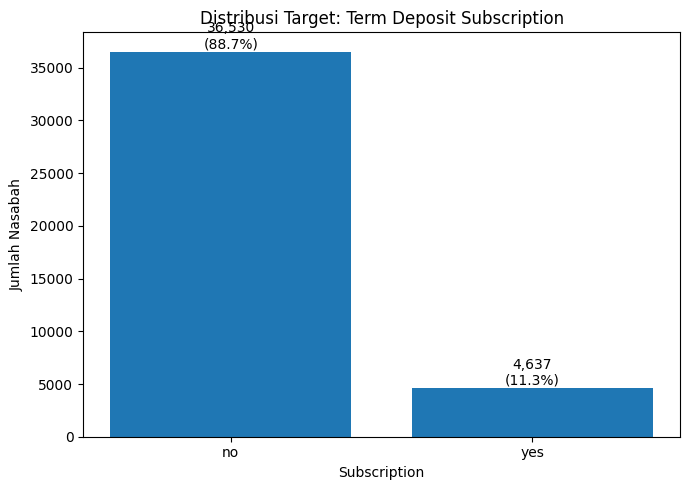

In [16]:
# Target distribution
target_dist = df["y"].value_counts()
target_pct = df["y"].value_counts(normalize=True).mul(100).round(2)

fig, ax = plt.subplots(figsize=(7, 5))
bars = ax.bar(target_dist.index, target_dist.values)
ax.set_title("Distribusi Target: Term Deposit Subscription")
ax.set_xlabel("Subscription")
ax.set_ylabel("Jumlah Nasabah")
for bar, val, pct in zip(bars, target_dist.values, target_pct.values):
    ax.text(bar.get_x() + bar.get_width()/2, val, f"{val:,}\n({pct:.1f}%)",
            ha="center", va="bottom")
plt.tight_layout()
plt.show()

### 4.1.2 Distribusi Fitur Numerik

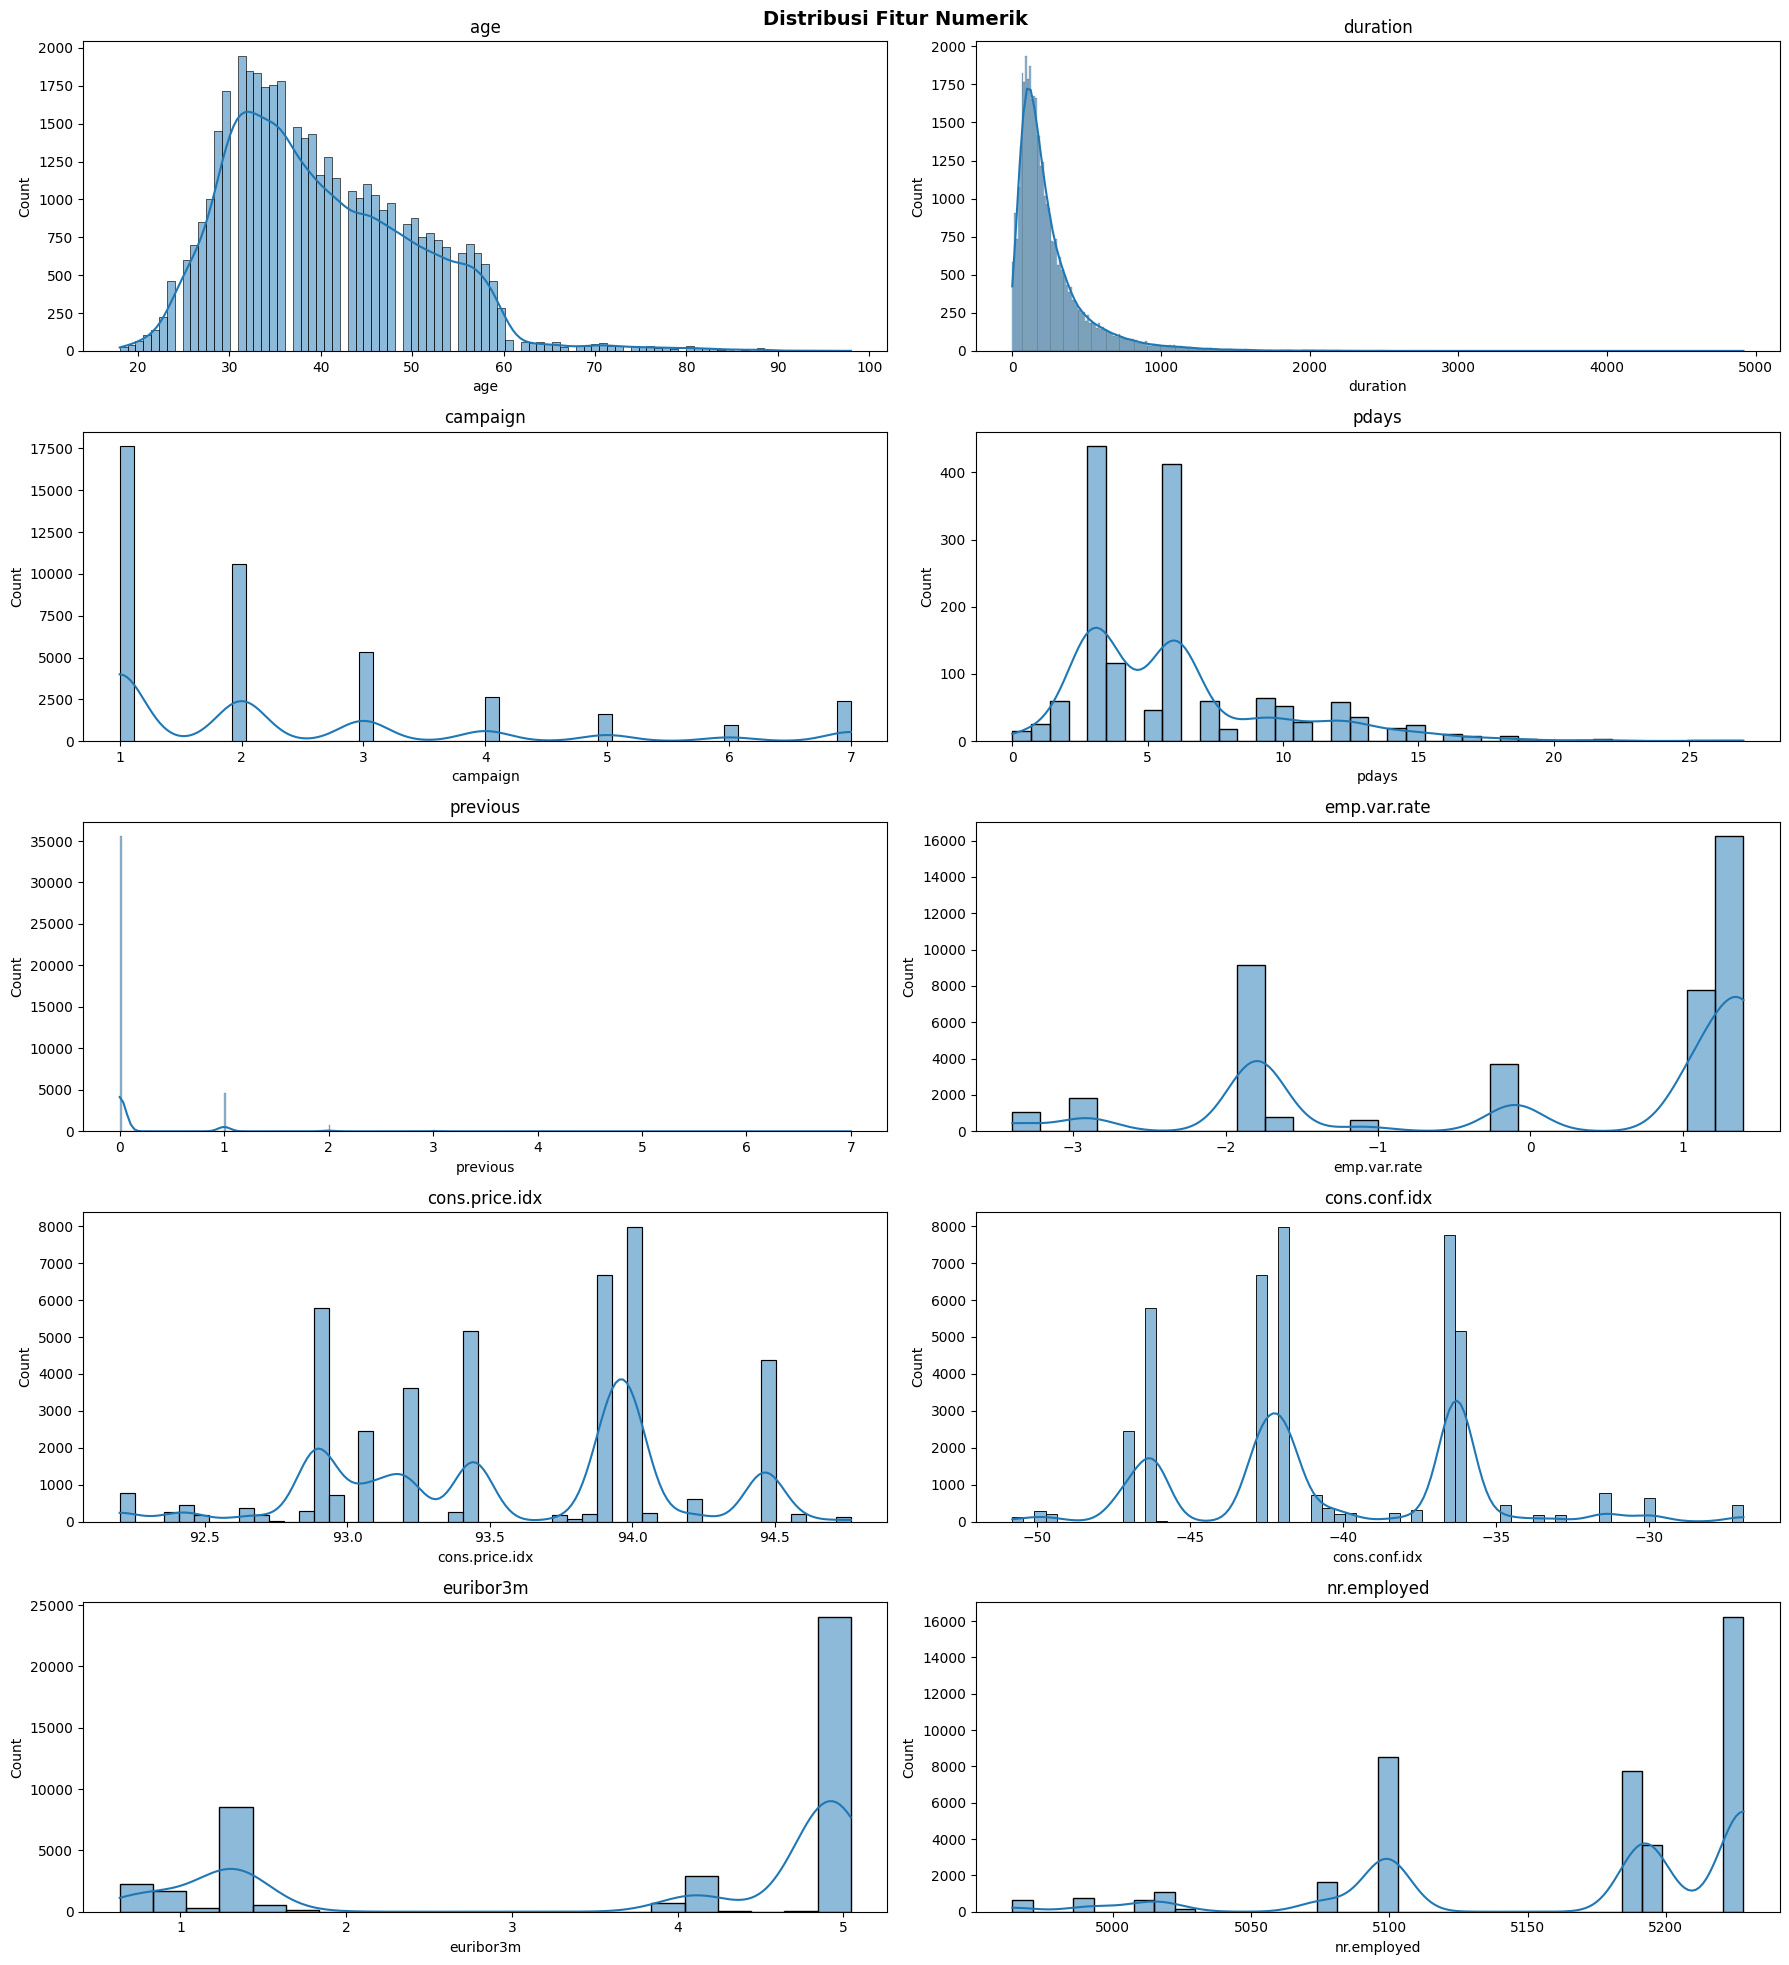

In [17]:
numeric_cols = df.select_dtypes(include=np.number).columns.tolist()
numeric_features = [c for c in numeric_cols if c != "y"]

fig, axes = plt.subplots(5, 2, figsize=(18, 20))
for ax, col in zip(axes.flat, numeric_features):
    sns.histplot(data=df, x=col, kde=True, ax=ax)
    ax.set_title(col)
plt.suptitle('Distribusi Fitur Numerik', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [18]:
df["pdays"].dtype

dtype('float64')

### 4.1.3 Distribusi Fitur Kategorikal

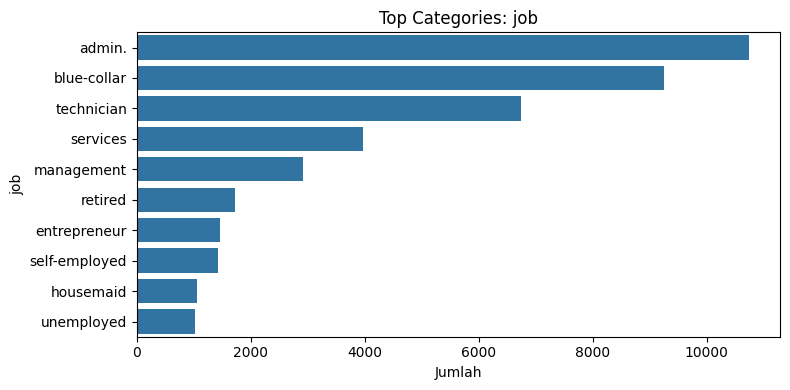

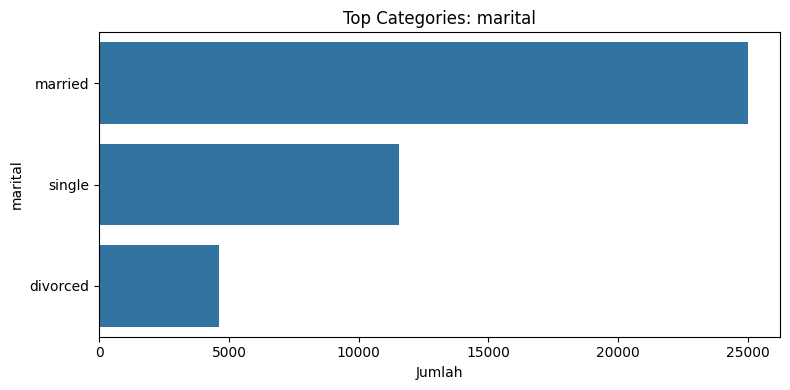

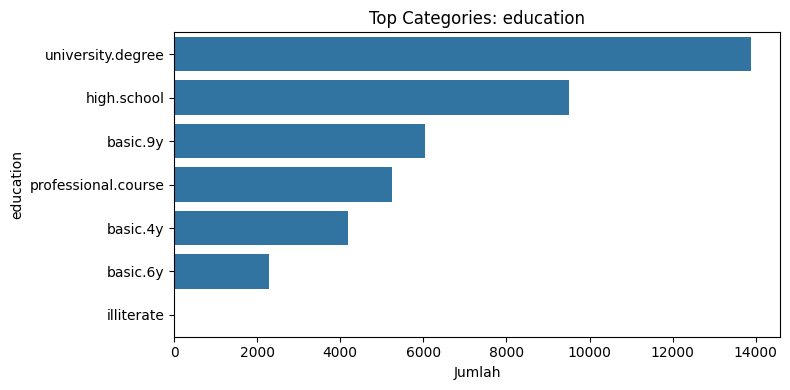

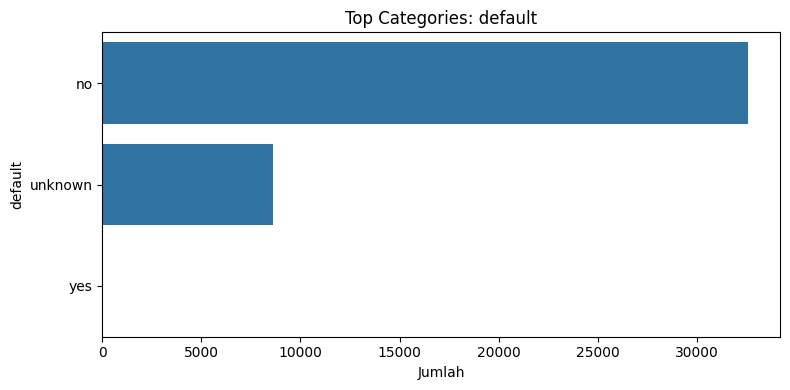

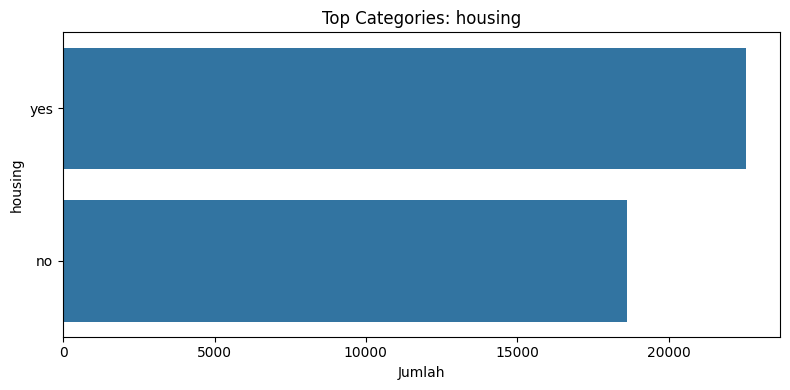

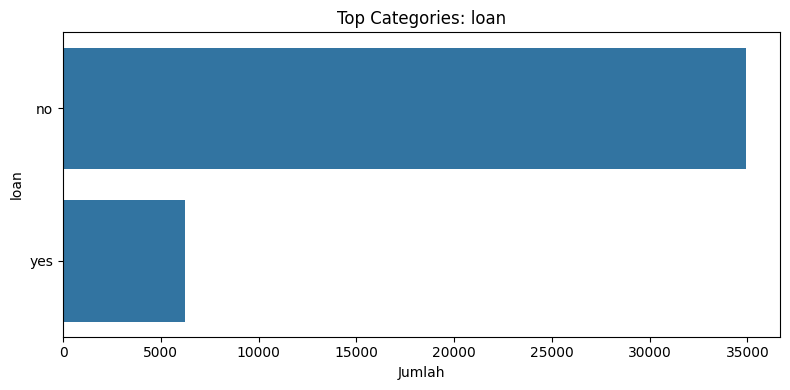

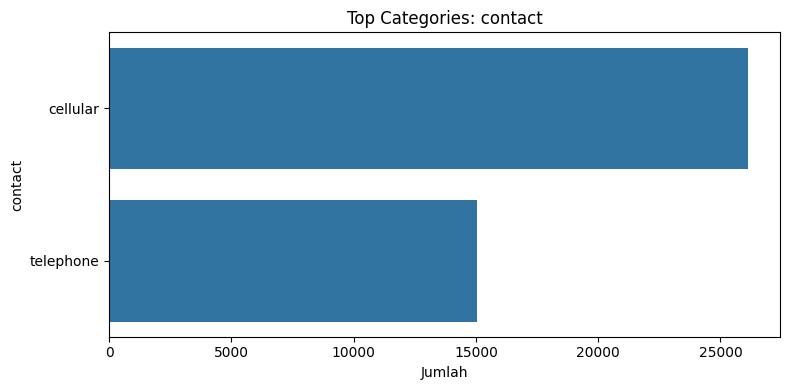

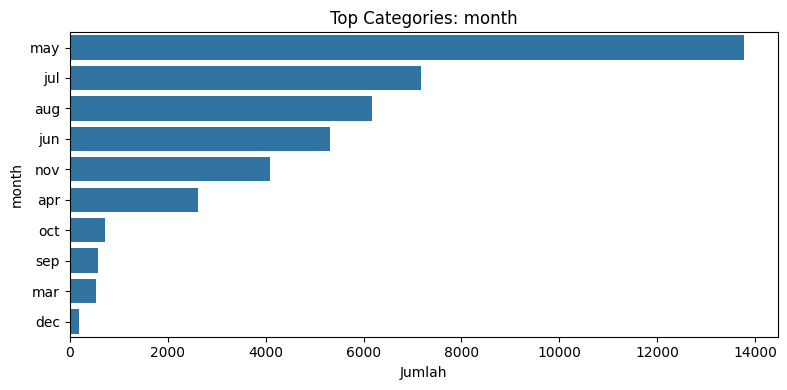

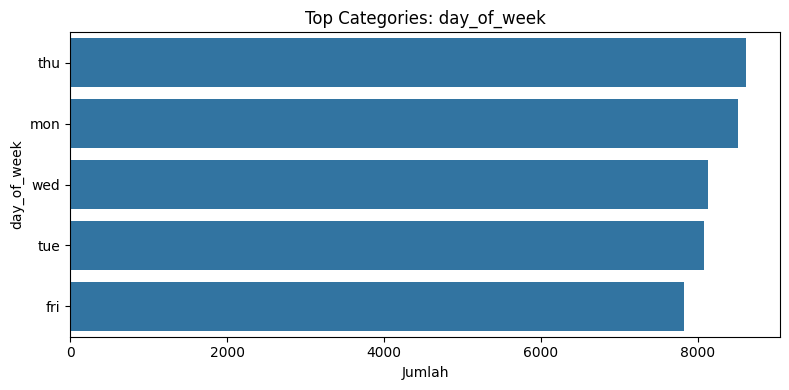

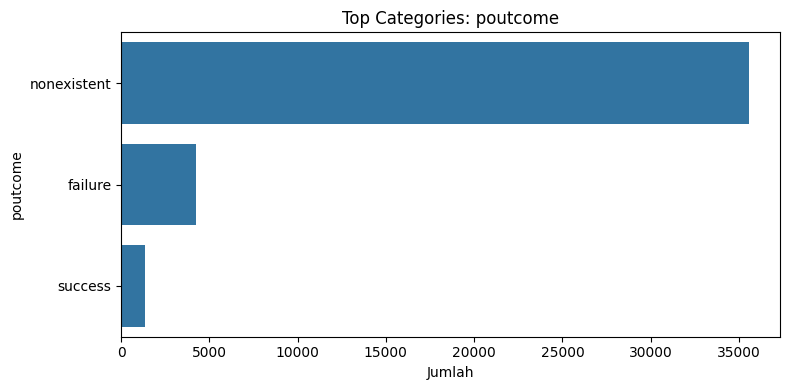

In [19]:
categorical_features = [c for c in cat_cols if c != "y"]

for col in categorical_features:
    counts = df[col].value_counts().head(10)
    plt.figure(figsize=(8, 4))
    sns.barplot(x=counts.values, y=counts.index)
    plt.title(f"Top Categories: {col}")
    plt.xlabel("Jumlah")
    plt.ylabel(col)
    plt.tight_layout()
    plt.show()

## **4.2 Bivariate Analysis**

### 4.2.1 Numerical vs Subscription

In [20]:
subscription_group = df.groupby("y")[numeric_cols].mean().T
subscription_group.columns = ["no", "yes"]
print("Rata-rata Fitur Numerik per Kelas Subscription:")
print(subscription_group.round(2))

Rata-rata Fitur Numerik per Kelas Subscription:
                               no      yes
age                         39.91    40.92
duration                   220.89   553.19
campaign                     2.38     2.00
pdays                        6.20     5.92
previous                     0.13     0.49
emp.var.rate                 0.25    -1.23
cons.price.idx              93.60    93.36
cons.conf.idx              -40.59   -39.80
euribor3m                    3.81     2.12
nr.employed               5176.18  5095.14
was_previously_contacted     0.01     0.21


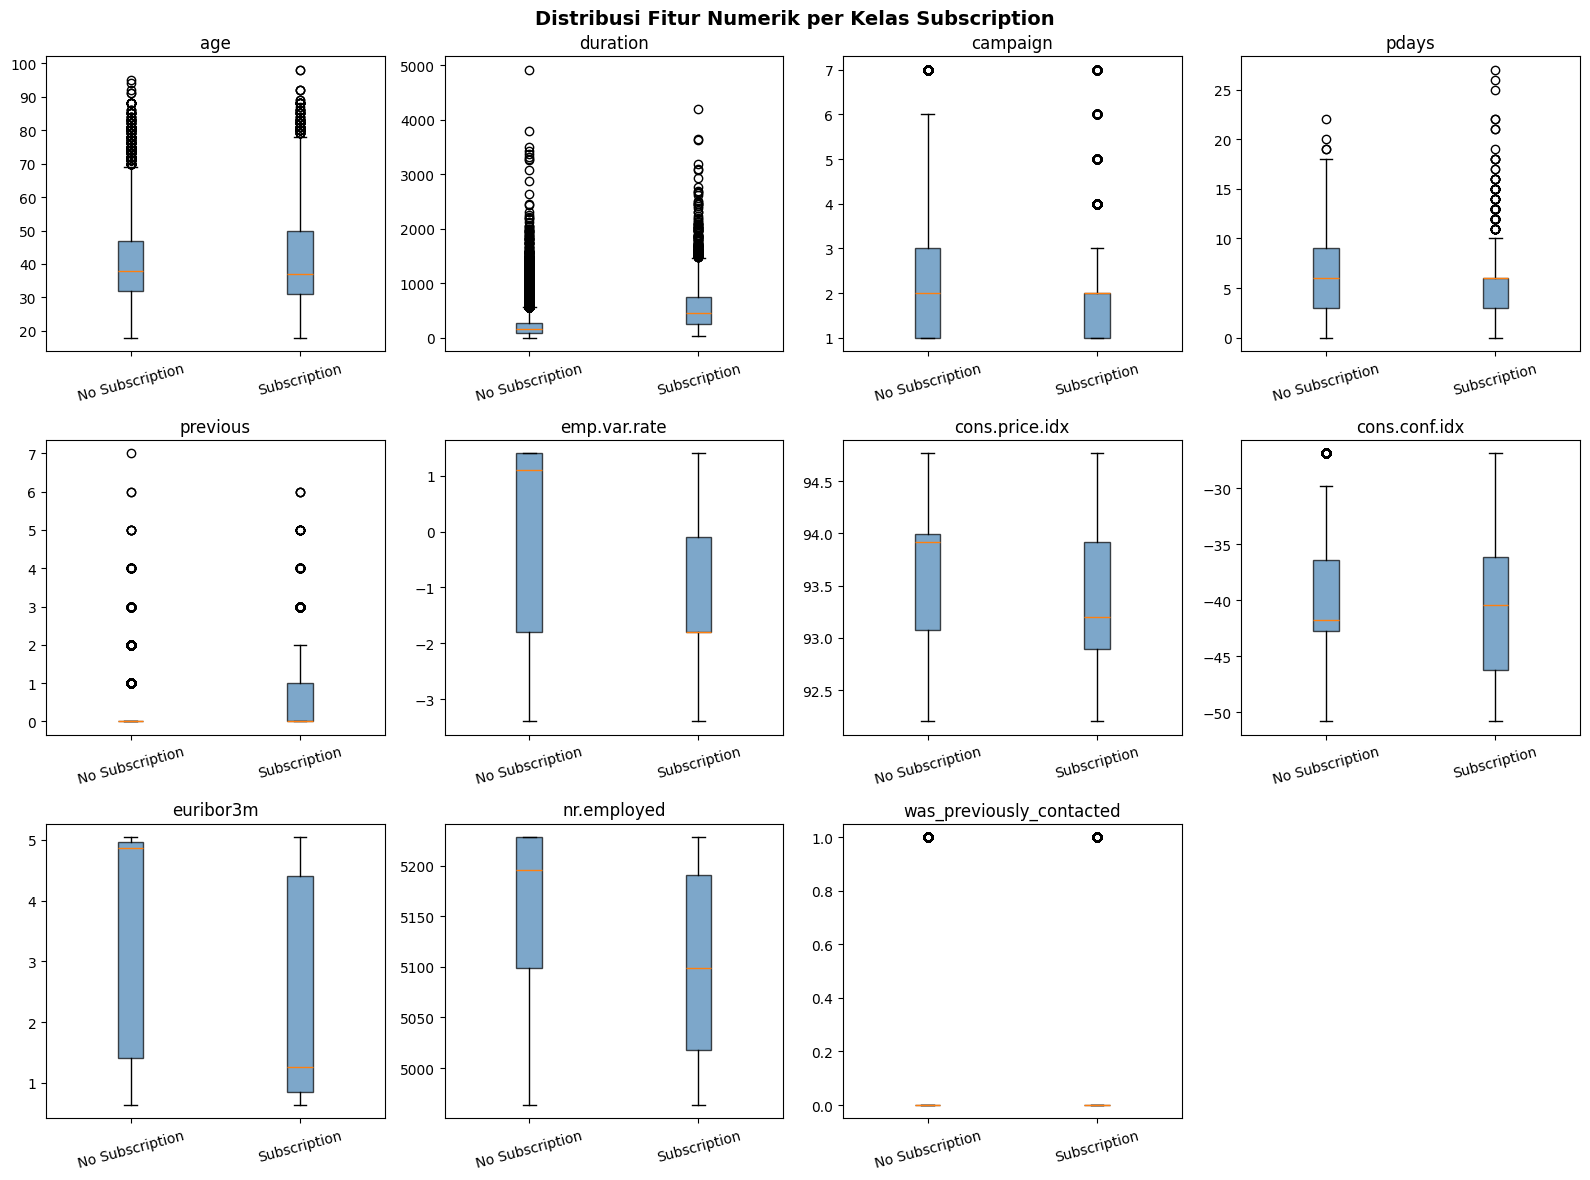

In [21]:
# Pastikan numeric_features berisi nama kolom numerik
n_cols = len(numeric_features)
n_rows = (n_cols + 3) // 4   # maksimal 4 per baris

fig, axes = plt.subplots(n_rows, 4, figsize=(16, 4*n_rows))
axes = axes.flatten()

for i, col in enumerate(numeric_features):
    sub_no = df[df["y"]=="no"][col].dropna()
    sub_yes = df[df["y"]=="yes"][col].dropna()
    
    axes[i].boxplot([sub_no, sub_yes],
                    labels=["No Subscription", "Subscription"],
                    patch_artist=True,
                    boxprops=dict(facecolor="steelblue", alpha=0.7))
    axes[i].set_title(col)
    axes[i].tick_params(axis="x", rotation=15)

# Matikan axes kosong
for j in range(len(numeric_features), len(axes)):
    axes[j].axis("off")

plt.suptitle("Distribusi Fitur Numerik per Kelas Subscription",
             fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()


### 4.2.2 Kategorikal vs Subscription

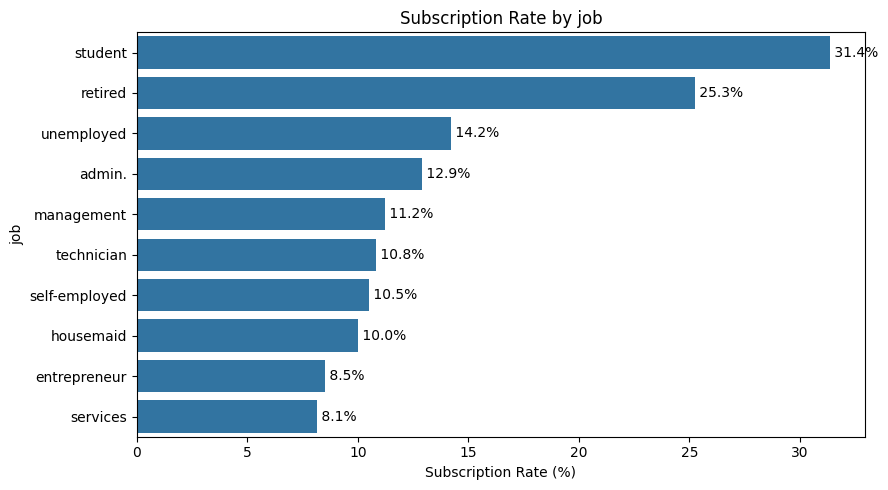

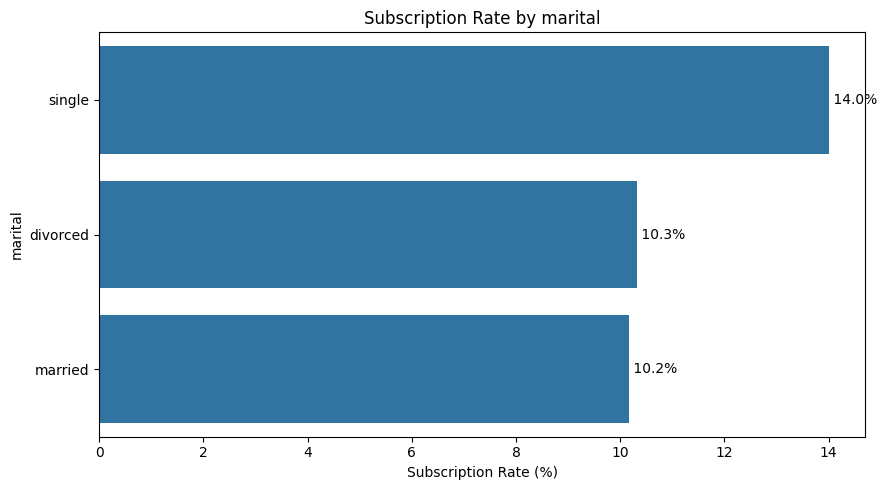

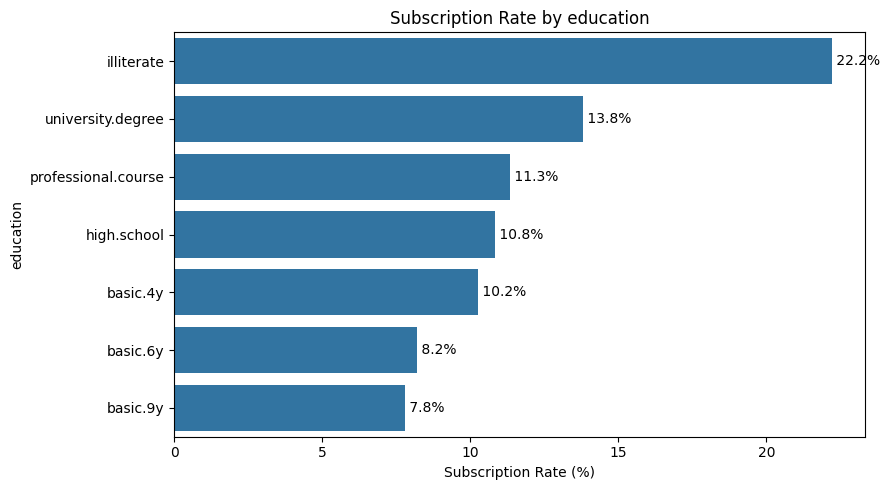

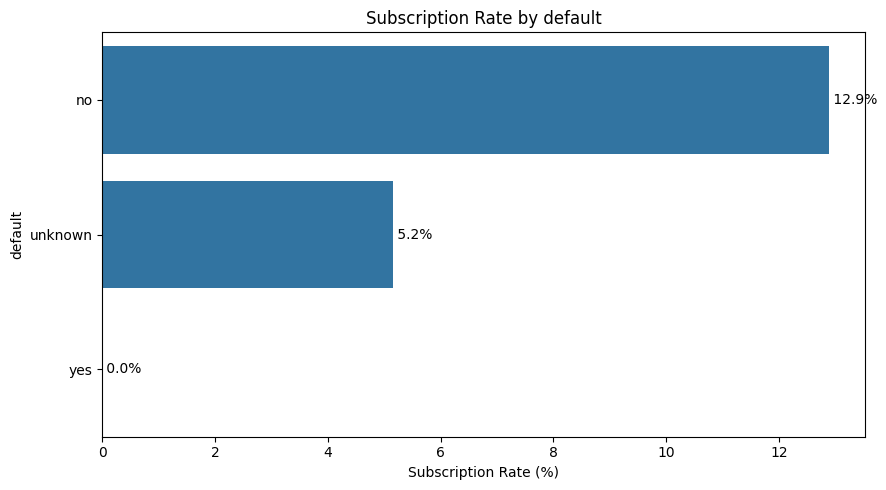

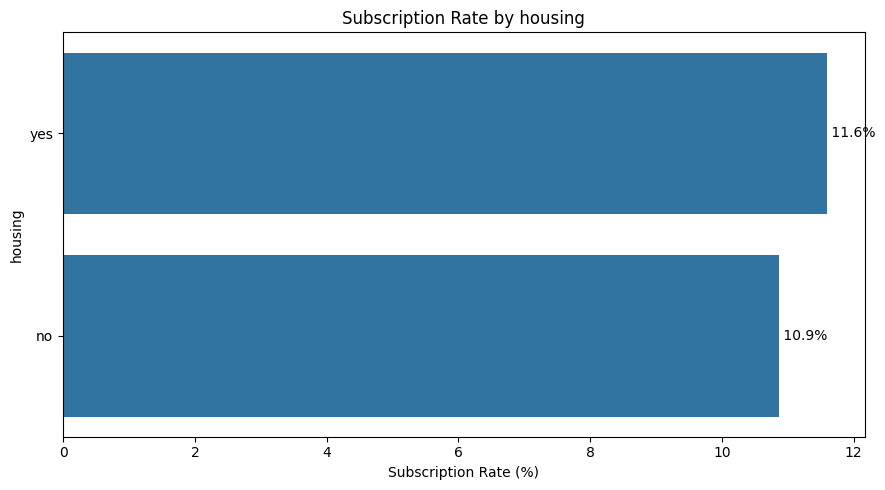

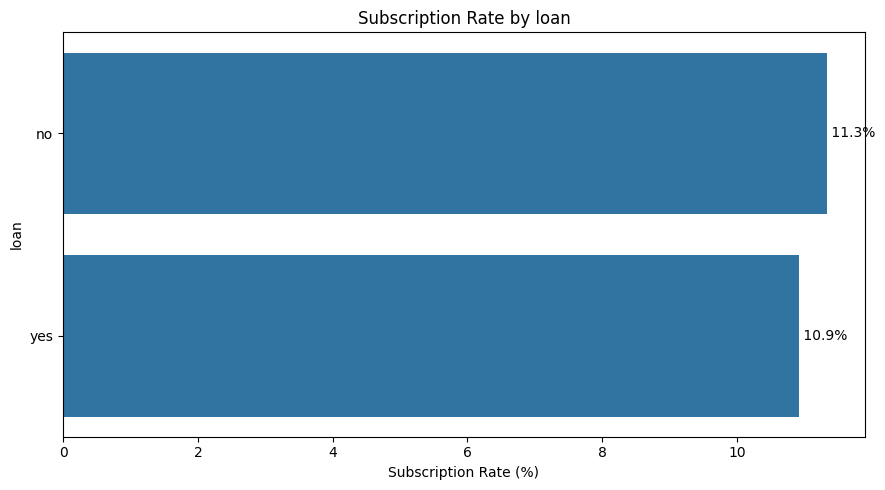

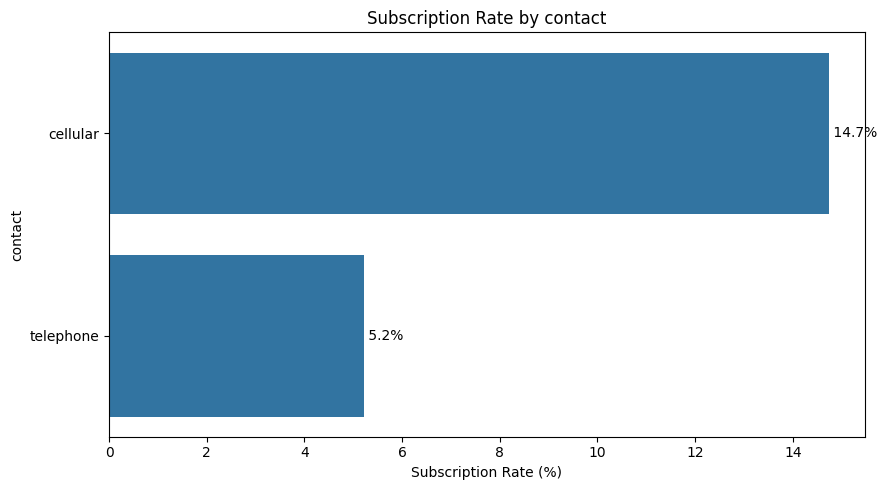

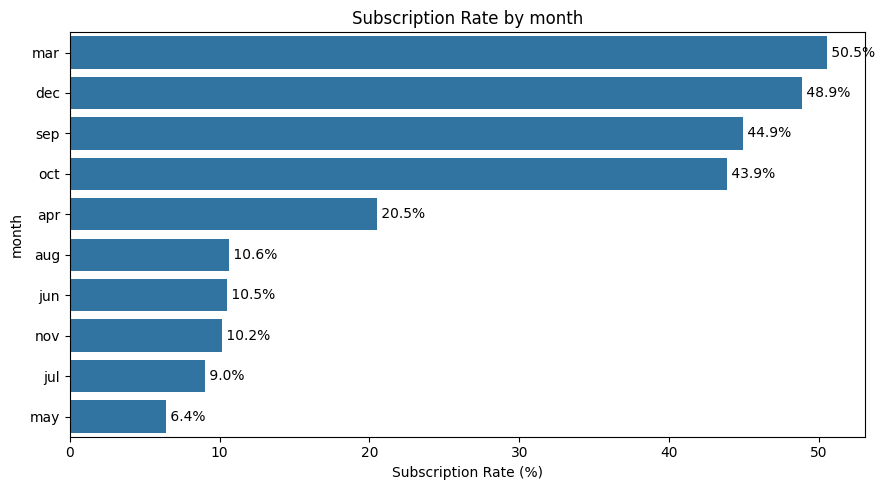

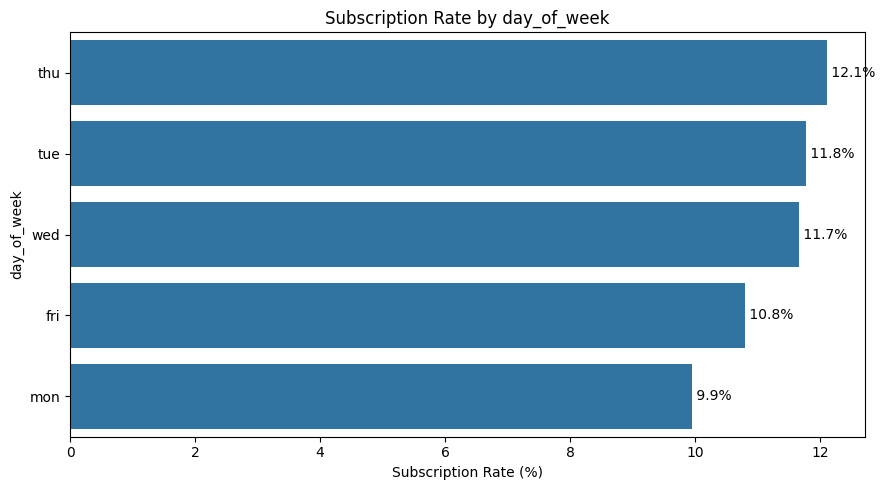

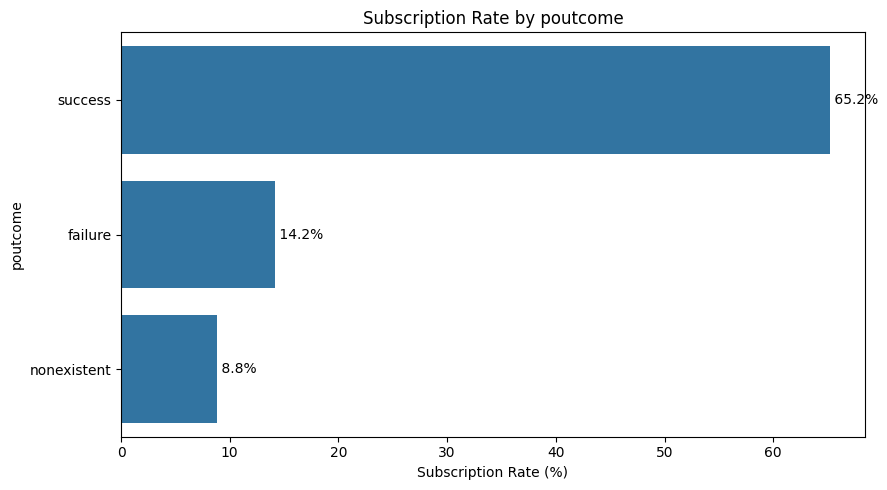

In [22]:
categorical_features = [c for c in cat_cols if c != "y"]
for col in categorical_features:

    # Hitung jumlah data per kategori
    count = df.groupby(col)["y"].count()

    # Hitung jumlah subscription (yes) per kategori
    yes_count = df.groupby(col)["y"].apply(
        lambda x: (x == "yes").sum()
    )

    # Hitung subscription rate
    rate = (yes_count / count * 100).round(2)

    # Gabungkan jumlah nasabah dan subscription rate
    result = pd.DataFrame({
        "Customer Count": count,
        "Subscription Rate (%)": rate
    })

    # Urutkan berdasarkan subscription rate
    result = result.sort_values(
        "Subscription Rate (%)",
        ascending=False
    ).head(10)

    plt.figure(figsize=(9, 5))

    ax = sns.barplot(
        data=result,
        x="Subscription Rate (%)",
        y=result.index
    )

    plt.title(f"Subscription Rate by {col}")
    plt.xlabel("Subscription Rate (%)")
    plt.ylabel(col)

    # Tambahkan label rate
    for i, value in enumerate(result["Subscription Rate (%)"]):
        ax.text(
            value,
            i,
            f" {value:.1f}%",
            va="center"
        )

    plt.tight_layout()
    plt.show()

## **4.3 Correlation & Multicollinearity Check**

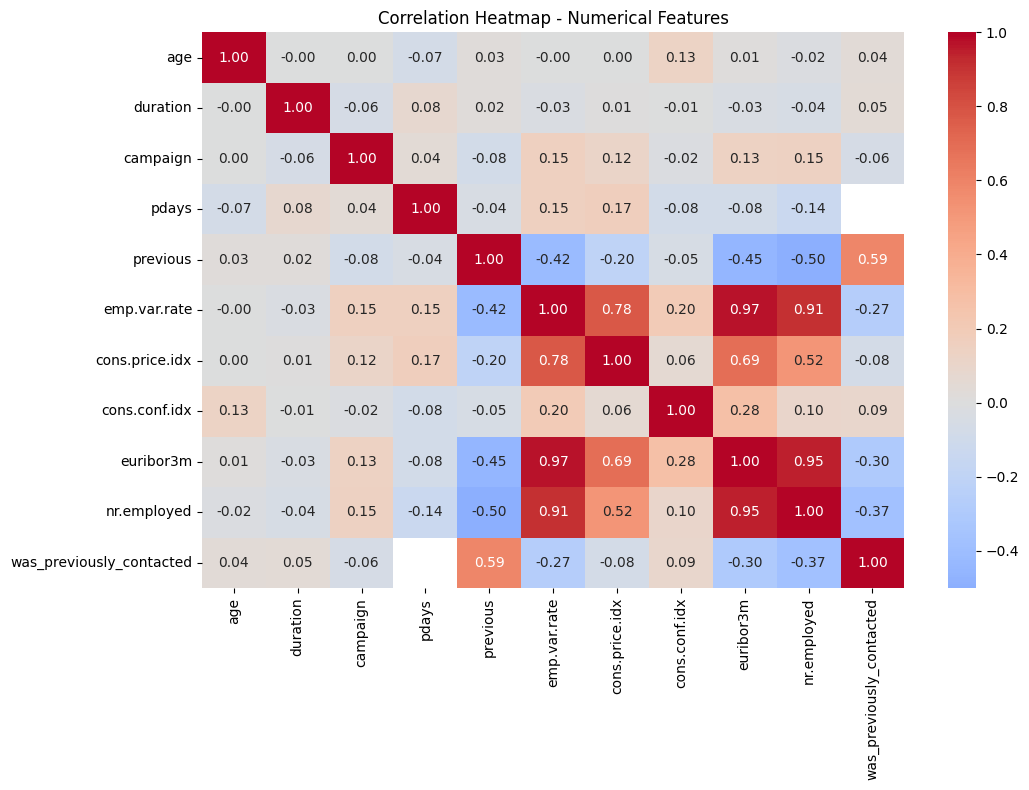

In [23]:
# Correlation heatmap
corr = df[numeric_features].corr()

plt.figure(figsize=(11, 8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlation Heatmap - Numerical Features")
plt.tight_layout()
plt.show()

### **Analisis Fitur Terpilih vs Subscription**

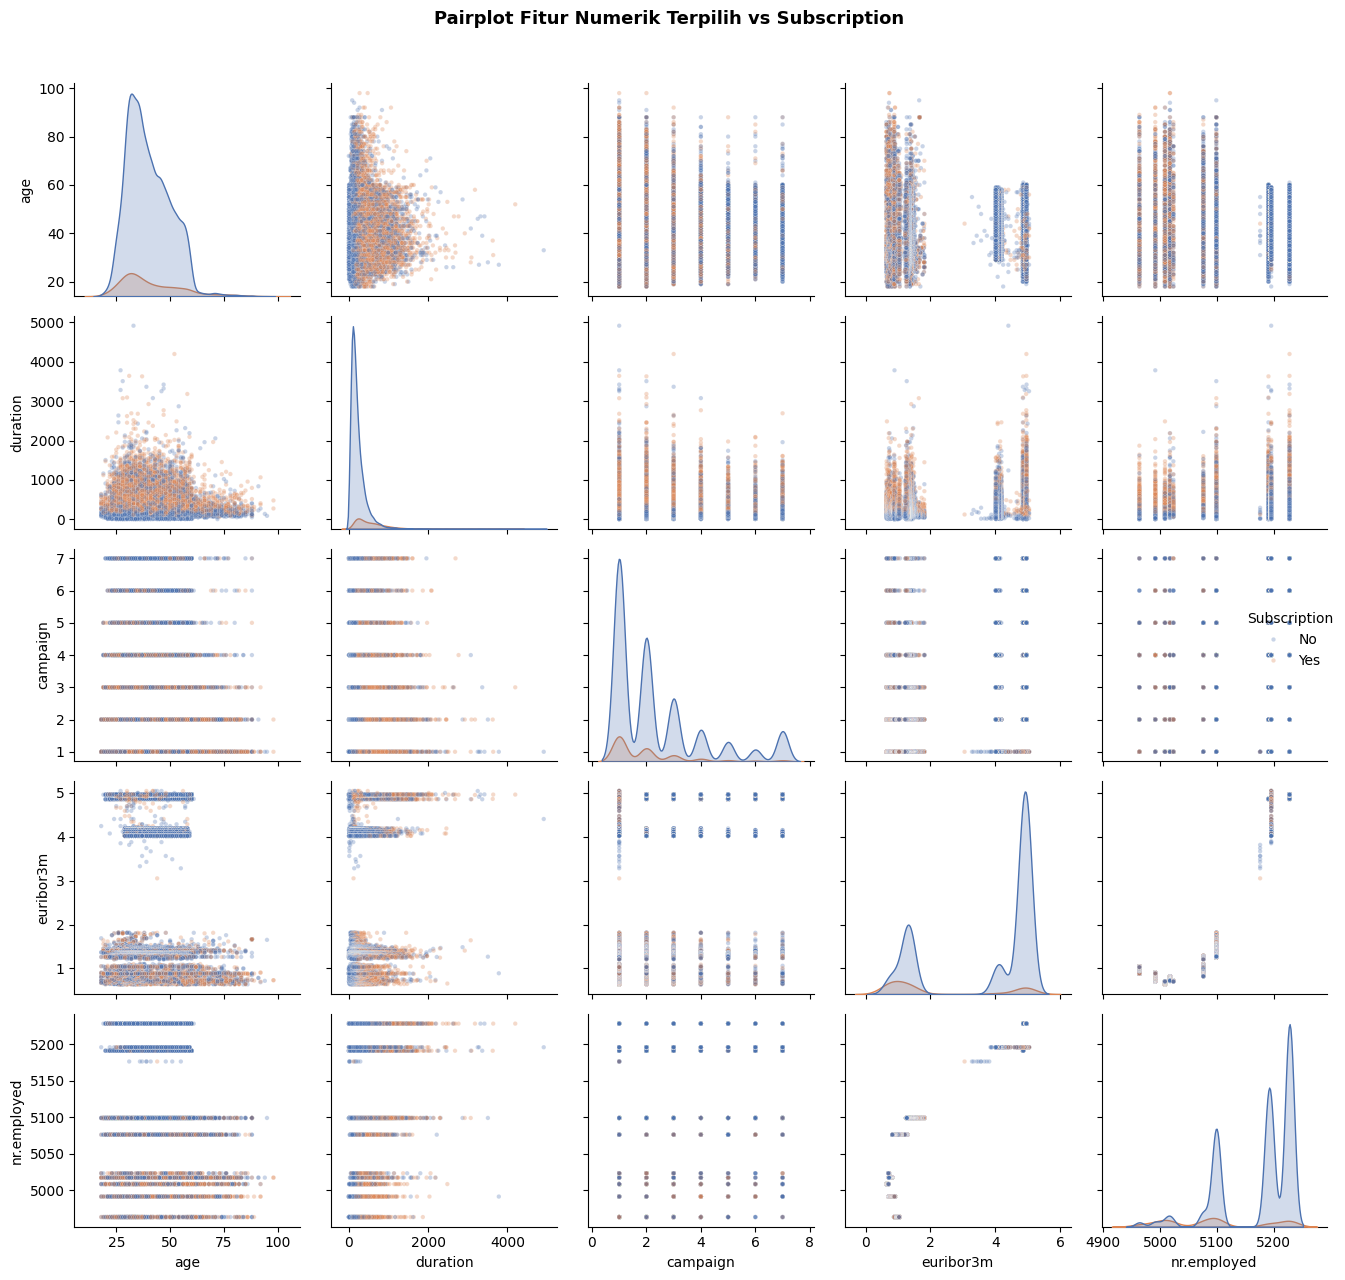

In [24]:
selected_num = ['age', 'duration', 'campaign', 'euribor3m', 'nr.employed']

df_pairplot = df.loc[df.index, selected_num + ['y']].dropna().copy()
df_pairplot['Subscription'] = df_pairplot['y'].map({'no': 'No', 'yes': 'Yes'})

sns.pairplot(df_pairplot, hue='Subscription', palette={'No': '#4C72B0', 'Yes': '#DD8452'},
             vars=selected_num, plot_kws={'alpha': 0.3, 's': 10},
             diag_kind='kde')
plt.suptitle('Pairplot Fitur Numerik Terpilih vs Subscription', y=1.02, fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [25]:
print(df[selected_num].describe())
print(df['y'].value_counts())

                age      duration      campaign     euribor3m   nr.employed
count  41167.000000  41167.000000  41167.000000  41167.000000  41167.000000
mean      40.026065    258.321277      2.333762      3.621676   5167.048563
std       10.418017    259.296445      1.701360      1.734264     72.247678
min       18.000000      1.000000      1.000000      0.634000   4963.600000
25%       32.000000    102.000000      1.000000      1.344000   5099.100000
50%       38.000000    180.000000      2.000000      4.857000   5191.000000
75%       47.000000    319.000000      3.000000      4.961000   5228.100000
max       98.000000   4918.000000      7.000000      5.045000   5228.100000
y
no     36530
yes     4637
Name: count, dtype: int64


# **Section 5. Data Preparation**

## **5.1 Initialization**

In [26]:
# Target encoding
df["y"] = df["y"].map({"no": 0, "yes": 1})

# define feature and target
feature = df.drop(columns="y")
target = df["y"]


 ## **5.2 Constructing Training and Testing Data**

In [27]:
x_train, x_test, y_train, y_test = train_test_split(
    feature, target, test_size=0.2, random_state=RANDOM_STATE, stratify=target
)

# TODO: reset index
x_train = x_train.reset_index(drop=True)
y_train = y_train.reset_index(drop=True)
x_test  = x_test.reset_index(drop=True)
y_test = y_test.reset_index(drop=True)

print("Train shape:", x_train.shape)
print("Test shape :", x_test.shape)

print("\ny_train distribution:")

Train shape: (32933, 21)
Test shape : (8234, 21)

y_train distribution:


## **5.3 Handling Imbalanced Data**

In [28]:
# Cek distribusi kelas
print(df["y"].value_counts())
print(df['y'].value_counts(normalize=True) * 100)
print("Class imbalance terdeteksi (~89% kelas no, ~11% kelas yes).")
print("Strategi: SMOTE akan diterapkan di dalam Pipeline pada data training saja.")
print("SMOTE TIDAK diterapkan pada data testing agar evaluasi tetap realistis.")

y
0    36530
1     4637
Name: count, dtype: int64
y
0    88.736124
1    11.263876
Name: proportion, dtype: float64
Class imbalance terdeteksi (~89% kelas no, ~11% kelas yes).
Strategi: SMOTE akan diterapkan di dalam Pipeline pada data training saja.
SMOTE TIDAK diterapkan pada data testing agar evaluasi tetap realistis.


## **5.4 Data Transformation (Feature Engineering)**

In [29]:
# Numerical features
numeric_features = [
    c for c in x_train.select_dtypes(include=np.number).columns
]

# Categorical features
categorical_features = [
    c for c in x_train.select_dtypes(
        include=["object"]
    ).columns
]

# Binary feature
binary_features = [
    "was_previously_contacted"
]

# Jangan masukkan binary ke numerical pipeline
numeric_features = [
    c for c in numeric_features
    if c not in binary_features
]

print("Numerical:")
print(numeric_features)

print("\nBinary:")
print(binary_features)

print("\nCategorical:")
print(categorical_features)

Numerical:
['age', 'duration', 'campaign', 'pdays', 'previous', 'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed']

Binary:
['was_previously_contacted']

Categorical:
['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'day_of_week', 'poutcome']


In [30]:
# Preprocessing
numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", RobustScaler())
])

categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_pipeline, numeric_features),
        ("cat", categorical_pipeline, categorical_features),
        ("binary", "passthrough", binary_features)
    ]
)

# base model with resampling
base_pipeline = ImbPipeline([
    ("fitur_engineering", preprocessor),
    ("fitur_resampling", SMOTE(random_state=RANDOM_STATE)),
    ("feature_selection", SelectKBest()),
    ("classifier", LogisticRegression(random_state=RANDOM_STATE))
])

## **5.5 Feature Selection**

In [31]:
base_pipeline.fit(x_train, y_train)

,steps,"[('fitur_engineering', ...), ('fitur_resampling', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string read

In [32]:
# 1. Ambil object yang sudah di fit
preprocessor_fitted = base_pipeline.named_steps["fitur_engineering"]
selector_fitted = base_pipeline.named_steps["feature_selection"]

# 2. Nama fitur setelah preprocessing
feature_names = preprocessor_fitted.get_feature_names_out()

# 3. Mask fitur yang dipilih SelectBest
selected_mask = selector_fitted.get_support()

# 4. Gabungkan nama fitur yang lolos seleksi
selected_features = feature_names[selected_mask]

print(f"Jumlah fitur sebelum seleksi : {len(feature_names)}")
print(f"Jumlah fitur setelah seleksi : {len(selected_features)}")
print(selected_features)

Jumlah fitur sebelum seleksi : 59
Jumlah fitur setelah seleksi : 10
['num__duration' 'num__previous' 'num__emp.var.rate' 'num__euribor3m'
 'num__nr.employed' 'cat__contact_cellular' 'cat__contact_telephone'
 'cat__poutcome_nonexistent' 'cat__poutcome_success'
 'binary__was_previously_contacted']


## **5.6 Overview**

In [33]:
print("=" * 50)
print("RINGKASAN DATA PREPARATION")
print("=" * 50)
print(f"Training data : {x_train.shape[0]} baris x {x_train.shape[1]} kolom")
print(f"Testing data  : {x_test.shape[0]} baris x {x_test.shape[1]} kolom")
print(f"Jumlah fitur  : {len(feature)}")

RINGKASAN DATA PREPARATION
Training data : 32933 baris x 21 kolom
Testing data  : 8234 baris x 21 kolom
Jumlah fitur  : 41167


# **Section 6. Model Development**

## **6.1. Initialization**

In [34]:
# F2 scorer
f2_scorer = make_scorer(fbeta_score, beta=2)

# cross validation
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

# scoring
scoring = {
    'recall'   : 'recall',
    'precision': 'precision',
    'f1'       : 'f1',
    'roc_auc'  : 'roc_auc',
    'f2'       : f2_scorer
}

def run_cv(base_pipeline, x_train, y_train):
    """Jalankan cross-validation dan kembalikan ringkasan metrik."""
    results = cross_validate(base_pipeline, x_train, y_train, cv=cv, scoring=scoring, n_jobs=-1)
    summary = {}
    for m in scoring:
        scores = results[f'test_{m}']
        summary[m] = {'mean': scores.mean(), 'std': scores.std()}
    return summary

print("Cross-Validation: StratifiedKFold (5 fold)")
print("Metrik: Recall, Precision, F1, F2, ROC-AUC")

Cross-Validation: StratifiedKFold (5 fold)
Metrik: Recall, Precision, F1, F2, ROC-AUC


In [35]:
cv_result = run_cv(
    base_pipeline,
    x_train,
    y_train
)

In [36]:
# save to dataframe
cv_summary = pd.DataFrame(cv_result).T
cv_summary

,mean,std
recall,0.847978,0.014349
precision,0.425459,0.006097
f1,0.566593,0.007496
roc_auc,0.926757,0.004173
f2,0.707424,0.010055


## **6.2 Developing the Model Pipeline**

In [37]:
def make_pipeline(model):
    """Buat ImbPipeline: preprocessor -> SMOTE -> model."""
    return ImbPipeline([
        ('preprocessor', preprocessor),
        ('smote',        SMOTE(random_state=RANDOM_STATE)),
        ('model',        model)
    ])

print("Pipeline: preprocessor -> SMOTE -> model")
print("Keunggulan: preprocessing di-fit hanya pada training fold (no data leakage).")

Pipeline: preprocessor -> SMOTE -> model
Keunggulan: preprocessing di-fit hanya pada training fold (no data leakage).


In [38]:
# Initialize model
logreg   = LogisticRegression(random_state=RANDOM_STATE, class_weight="balanced")
knn      = KNeighborsClassifier()
dt       = DecisionTreeClassifier(random_state=RANDOM_STATE, class_weight="balanced")
rf       = RandomForestClassifier(random_state=RANDOM_STATE, class_weight="balanced")
gb       = GradientBoostingClassifier(random_state=RANDOM_STATE)
adaboost = AdaBoostClassifier(random_state=RANDOM_STATE)

In [39]:
list_models = {
    "LogisticRegression"     : logreg,
    "KNN"                    : knn,
    "DecisionTreeClassifier" : dt,
    "RandomForestClassifier" : rf,
    "GradientBoost"          : gb,
    "AdaBoost"               : adaboost,
}

## **6.3 Model Benchmarking**

### 6.3.1 Model Benchmarking (with resampling)

In [40]:
# Benchmark model function
def benchmark_models(pipeline, list_models, x_train, y_train, 
                      scoring=f2_scorer, cv=5, random_state=RANDOM_STATE):
    """""
    Benchmark beberapa model classifier menggunakan cross-validation
    di atas satu pipeline yang sama (hanya step 'classifier' yang diganti).

    Parameters
    ----------
    pipeline : sklearn Pipeline
        Pipeline yang punya step bernama 'classifier' (mis. model_res_pipeline).
    list_models : dict
        {"nama_model": estimator, ...}
    x_train, y_train : array-like
        Data training.
    scoring : str
        Metric untuk cross_validate (default "f1").
    cv : int
        Jumlah fold untuk StratifiedKFold (default 5).
    random_state : int or None
        Untuk shuffle di StratifiedKFold, jika ingin reproducible.

    Returns
    -------
    pd.DataFrame
        Ringkasan mean & std train/test score per model, diurutkan
        berdasarkan mean_test_score tertinggi.
    """
    all_cv_result = []

    skf = StratifiedKFold(
        n_splits=cv,
        shuffle=random_state is not None,
        random_state=random_state
    )

    for name, model in list_models.items():
        classifier = pipeline.set_params(classifier=model)
        cv_result = cross_validate(
            estimator=classifier,
            X=x_train, y=y_train,
            cv=skf,
            scoring=scoring,
            return_train_score=True
        )
        all_cv_result.append({
            "name": name,
            "mean_train_score": np.mean(cv_result["train_score"]),
            "std_train_score": np.std(cv_result["train_score"]),
            "mean_test_score": np.mean(cv_result["test_score"]),
            "std_test_score": np.std(cv_result["test_score"])
        })

    df_result = pd.DataFrame(all_cv_result).sort_values(
        "mean_test_score", ascending=False
    ).reset_index(drop=True)

    return df_result

In [41]:
# With resampling
benchmark_models(
    base_pipeline, 
    list_models,
    x_train, 
    y_train, 
    scoring=f2_scorer,
    cv=5, 
    random_state=RANDOM_STATE
)

,name,mean_train_score,std_train_score,mean_test_score,std_test_score
0,GradientBoost,0.756974,0.001870,0.747823,0.005993
1,AdaBoost,0.731205,0.003271,0.729338,0.007610
2,KNN,0.789426,0.002019,0.714199,0.010010
3,LogisticRegression,0.707896,0.003013,0.707424,0.010055
4,RandomForestClassifier,0.973853,0.001364,0.643624,0.012688
5,DecisionTreeClassifier,0.962808,0.002148,0.600051,0.018691


### 6.3.2 Model Ensamble Benchmarking

### 6.3.2.1 Various Type

In [42]:
# model initialization
voting = VotingClassifier(estimators=[("rf", rf), ("dt", dt), ("knn", knn)])
stacking = StackingClassifier(estimators=[("rf", rf), ("dt", dt), ("knn", knn)],
                              final_estimator=gb)

In [43]:
# benchmark process
benchmark_various = benchmark_models(pipeline=base_pipeline, list_models={"voting": voting, "stacking": stacking}, x_train=x_train,y_train=y_train,
                    scoring=f2_scorer,
                    cv=5,
                    random_state=RANDOM_STATE)

In [44]:
benchmark_various

,name,mean_train_score,std_train_score,mean_test_score,std_test_score
0,stacking,0.936899,0.003905,0.701242,0.015284
1,voting,0.972147,0.001269,0.653477,0.013460


## **6.4 Tune Model**

In [45]:
from scipy.stats import randint, uniform
from sklearn.model_selection import RandomizedSearchCV

f2_scorer = make_scorer(fbeta_score, beta=2)

### **6.4.1 GradientBoost Tuning**

In [46]:
GB_PATH = '../model/GradientBoost_tuned.joblib'

if os.path.exists(GB_PATH):
    data           = joblib.load(GB_PATH)
    tuned_gb       = data['model']
    gb_cv_score    = joblib.load(GB_PATH)['best_score']
    print("GradientBoost loaded, skipping tuning.")
    print("Best F2 (CV)     :", round(gb_cv_score, 4))
else:
    param_dist_gb = {
        "model__n_estimators"    : randint(100, 400),
        "model__learning_rate"   : uniform(0.01, 0.2),
        "model__max_depth"       : randint(3, 7),
        "model__subsample"       : uniform(0.7, 0.3),
        "model__min_samples_leaf": randint(10, 50),
    }
    rs_gb = RandomizedSearchCV(
        make_pipeline(GradientBoostingClassifier(random_state=RANDOM_STATE)),
        param_distributions=param_dist_gb,
        n_iter=50, scoring=f2_scorer,
        cv=cv, n_jobs=-1, random_state=RANDOM_STATE,
        return_train_score=True
    )
    rs_gb.fit(x_train, y_train)
    tuned_gb       = rs_gb.best_estimator_
    gb_cv_score    = rs_gb.best_score_
    gb_best_params = rs_gb.best_params_
    os.makedirs(r'..\model', exist_ok=True)
    joblib.dump({'model': tuned_gb, 'best_score': gb_cv_score, 'best_params': gb_best_params}, GB_PATH)
    print("Best params (GB) :", gb_best_params)
    print("Best F2 (CV)     :", round(gb_cv_score, 4))

GradientBoost loaded, skipping tuning.
Best F2 (CV)     : 0.7556


#### Evaluation Before VS After Tuning

In [47]:
from sklearn.base import clone

base_gb = make_pipeline(GradientBoostingClassifier(random_state=RANDOM_STATE))
base_gb.fit(x_train, y_train)

tuned_gb.fit(x_train, y_train)

# Before
y_train_pred = base_gb.predict(x_train)
y_test_pred  = base_gb.predict(x_test)
print("Base GradientBoosting")
print(f"  Train F2 : {fbeta_score(y_train, y_train_pred, beta=2):.4f}")
print(f"  Test  F2 : {fbeta_score(y_test,  y_test_pred,  beta=2):.4f}")

# After
y_train_pred = tuned_gb.predict(x_train)
y_test_pred  = tuned_gb.predict(x_test)
print("\nTuned GradientBoosting")
print(f"  Train F2 : {fbeta_score(y_train, y_train_pred, beta=2):.4f}")
print(f"  Test  F2 : {fbeta_score(y_test,  y_test_pred,  beta=2):.4f}")

Base GradientBoosting
  Train F2 : 0.7496
  Test  F2 : 0.7349

Tuned GradientBoosting
  Train F2 : 0.7699
  Test  F2 : 0.7559


### **6.4.2 AdaBoost Tuning**

In [48]:
ADA_PATH = '../model/AdaBoost_tuned.joblib'

if os.path.exists(ADA_PATH):
    tuned_ada    = joblib.load(ADA_PATH)['model']
    ada_cv_score = joblib.load(ADA_PATH)['best_score']
    print("AdaBoost loaded, skipping tuning.")
    print("Best F2 (CV)     :", round(ada_cv_score, 4))
else:
    param_dist_ada = {
        "model__n_estimators" : randint(50, 300),
        "model__learning_rate": uniform(0.01, 1.5),
    }

    rs_ada = RandomizedSearchCV(
        make_pipeline(AdaBoostClassifier(random_state=RANDOM_STATE)),
        param_distributions=param_dist_ada,
        n_iter=50, scoring=f2_scorer,
        cv=cv, n_jobs=-1, random_state=RANDOM_STATE,
        return_train_score=True
    )
    rs_ada.fit(x_train, y_train)
    tuned_ada    = rs_ada.best_estimator_
    ada_cv_score = rs_ada.best_score_
    os.makedirs('../model', exist_ok=True)
    joblib.dump({'model': tuned_ada, 'best_score': ada_cv_score}, ADA_PATH)
    print("Best params (Ada):", rs_ada.best_params_)
    print("Best F2 (CV)     :", round(ada_cv_score, 4))

AdaBoost loaded, skipping tuning.
Best F2 (CV)     : 0.7346


#### Evaluation Before VS After Tuning

In [49]:
base_ada = make_pipeline(AdaBoostClassifier(random_state=RANDOM_STATE))
base_ada.fit(x_train, y_train)

# Before
y_train_pred = base_ada.predict(x_train)
y_test_pred  = base_ada.predict(x_test)
print("Base AdaBoost")
print(f"  Train F2 : {fbeta_score(y_train, y_train_pred, beta=2):.4f}")
print(f"  Test  F2 : {fbeta_score(y_test,  y_test_pred,  beta=2):.4f}")

# After
x_train_processed = tuned_gb.named_steps['preprocessor'].transform(x_train)
x_test_processed  = tuned_gb.named_steps['preprocessor'].transform(x_test)

y_train_pred = tuned_ada.predict(x_train_processed)
y_test_pred  = tuned_ada.predict(x_test_processed)
print("\nTuned AdaBoost")
print(f"  Train F2 : {fbeta_score(y_train, y_train_pred, beta=2):.4f}")
print(f"  Test  F2 : {fbeta_score(y_test,  y_test_pred,  beta=2):.4f}")

Base AdaBoost
  Train F2 : 0.7082
  Test  F2 : 0.7165

Tuned AdaBoost
  Train F2 : 0.7364
  Test  F2 : 0.7447


### **6.4.3 Logistic Regression Tuning**

In [50]:
LR_PATH = '../model/LogReg_tuned.joblib'

if os.path.exists(LR_PATH):
    tuned_logreg = joblib.load(LR_PATH)['model']
    lr_cv_score  = joblib.load(LR_PATH)['best_score']
    print("LogReg loaded, skipping tuning.")
    print("Best F2 (CV)     :", round(lr_cv_score, 4))
else:
    param_dist_logreg = {
        "model__C"       : uniform(0.001, 10),
        "model__solver"  : ["lbfgs", "liblinear"],
        "model__max_iter": [300, 500, 1000],
    }

    rs_logreg = RandomizedSearchCV(
        make_pipeline(LogisticRegression(
            random_state=RANDOM_STATE, class_weight="balanced")),
        param_distributions=param_dist_logreg,
        n_iter=30, scoring=f2_scorer,
        cv=cv, n_jobs=-1, random_state=RANDOM_STATE,
        return_train_score=True
    )
    rs_logreg.fit(x_train, y_train)
    tuned_logreg = rs_logreg.best_estimator_
    lr_cv_score  = rs_logreg.best_score_
    os.makedirs('../model', exist_ok=True)
    joblib.dump({'model': tuned_logreg, 'best_score': lr_cv_score}, LR_PATH)
    print("Best params (LR) :", rs_logreg.best_params_)
    print("Best F2 (CV)     :", round(lr_cv_score, 4))

LogReg loaded, skipping tuning.
Best F2 (CV)     : 0.7355


#### Evaluation Before VS After Tuning

In [51]:
base_logreg = make_pipeline(LogisticRegression(random_state=RANDOM_STATE, class_weight="balanced"))
base_logreg.fit(x_train, y_train)

# Before
y_train_pred = base_logreg.predict(x_train)
y_test_pred  = base_logreg.predict(x_test)
print("Base Logistic Regression")
print(f"  Train F2 : {fbeta_score(y_train, y_train_pred, beta=2):.4f}")
print(f"  Test  F2 : {fbeta_score(y_test,  y_test_pred,  beta=2):.4f}")

# After
y_train_pred = tuned_logreg.predict(x_train)
y_test_pred  = tuned_logreg.predict(x_test)
print("\nTuned Logistic Regression")
print(f"  Train F2 : {fbeta_score(y_train, y_train_pred, beta=2):.4f}")
print(f"  Test  F2 : {fbeta_score(y_test,  y_test_pred,  beta=2):.4f}")

Base Logistic Regression
  Train F2 : 0.7378
  Test  F2 : 0.7516

Tuned Logistic Regression
  Train F2 : 0.7377
  Test  F2 : 0.7519


### **6.4.4 Comparing Tuning Results**

In [52]:
tuning_rows = []

# Preprocess x_test dulu for model that doesn't have full pipeline
preprocessor = tuned_gb.named_steps['preprocessor']
x_test_processed = preprocessor.transform(x_test)

for name, tuned_model, cv_score in [
    ("GradientBoosting", tuned_gb,     gb_cv_score),
    ("AdaBoost",         tuned_ada,    ada_cv_score),
    ("LogReg",           tuned_logreg, lr_cv_score),
]:
    # GB punya full pipeline, Ada dan LR tidak
    if hasattr(tuned_model, 'named_steps'):
        y_pred  = tuned_model.predict(x_test)
        y_proba = tuned_model.predict_proba(x_test)[:, 1]
    else:
        y_pred  = tuned_model.predict(x_test_processed)
        y_proba = tuned_model.predict_proba(x_test_processed)[:, 1]

    tuning_rows.append({
        "Model"         : name,
        "Best CV F2"    : round(cv_score, 4),
        "Test F2"       : round(fbeta_score(y_test, y_pred, beta=2), 4),
        "Test Recall"   : round(recall_score(y_test, y_pred), 4),
        "Test Precision": round(precision_score(y_test, y_pred), 4),
        "ROC-AUC"       : round(roc_auc_score(y_test, y_proba), 4),
    })

tuning_df = pd.DataFrame(tuning_rows).sort_values("Test F2", ascending=False).reset_index(drop=True)
display(tuning_df)

,Model,Best CV F2,Test F2,Test Recall,Test Precision,ROC-AUC
0,GradientBoosting,0.7556,0.7559,0.8932,0.4681,0.9439
1,LogReg,0.7355,0.7519,0.8943,0.4593,0.9410
2,AdaBoost,0.7346,0.7447,0.8749,0.4669,0.9349


### **6.4.5 Choosing Best Model**

In [53]:
best_model = tuned_gb

os.makedirs('../model', exist_ok=True)
joblib.dump({'model': tuned_gb,     'best_score': gb_cv_score},  '../model/GradientBoost_tuned.joblib')
joblib.dump({'model': tuned_ada,    'best_score': ada_cv_score},  '../model/AdaBoost_tuned.joblib')
joblib.dump({'model': tuned_logreg, 'best_score': lr_cv_score},   '../model/LogReg_tuned.joblib')
joblib.dump({'model': best_model,   'best_score': gb_cv_score},   '../model/best_model.joblib')
print("All models saved.")

clf = best_model.named_steps['model']
print(f"Best model  : {clf.__class__.__name__}")
print(f"Parameters  :")
for param, value in clf.get_params().items():
    print(f"  {param}: {value}")
print(f"\nTest F2     : {fbeta_score(y_test, best_model.predict(x_test), beta=2):.4f}")
print(f"Test Recall : {recall_score(y_test, best_model.predict(x_test)):.4f}")
print(f"Test ROC-AUC: {roc_auc_score(y_test, best_model.predict_proba(x_test)[:,1]):.4f}")

All models saved.
Best model  : GradientBoostingClassifier
Parameters  :
  ccp_alpha: 0.0
  criterion: friedman_mse
  init: None
  learning_rate: 0.012074830777139991
  loss: log_loss
  max_depth: 5
  max_features: None
  max_leaf_nodes: None
  min_impurity_decrease: 0.0
  min_samples_leaf: 32
  min_samples_split: 2
  min_weight_fraction_leaf: 0.0
  n_estimators: 225
  n_iter_no_change: None
  random_state: 9
  subsample: 0.7039966036794155
  tol: 0.0001
  validation_fraction: 0.1
  verbose: 0
  warm_start: False

Test F2     : 0.7559
Test Recall : 0.8932
Test ROC-AUC: 0.9439


## **6.5 Analyze Model**

&emsp;&emsp;&emsp;Analisis model dilakukan pada data testing untuk mengevaluasi performa nyata model di luar data training. Metrik yang digunakan: **Confusion Matrix**, **Classification Report** (Precision, Recall, F1, F2), dan **ROC-AUC**.

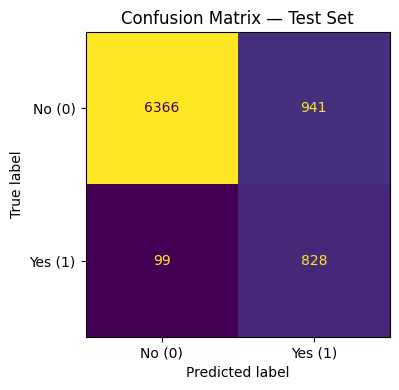

Classification Report:
              precision    recall  f1-score   support

          No       0.98      0.87      0.92      7307
         Yes       0.47      0.89      0.61       927

    accuracy                           0.87      8234
   macro avg       0.73      0.88      0.77      8234
weighted avg       0.93      0.87      0.89      8234

Recall    : 0.8932
Precision : 0.4681
F2-Score  : 0.7559
ROC-AUC   : 0.9439


In [54]:
# Evaluasi model terbaik pada data testing
y_pred  = best_model.predict(x_test)
y_proba = best_model.predict_proba(x_test)[:, 1]

# Confusion Matrix
fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, ax=ax,
    display_labels=["No (0)", "Yes (1)"], colorbar=False)
ax.set_title("Confusion Matrix — Test Set")
plt.tight_layout()
plt.show()

# Classification Report
print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=["No", "Yes"]))

# Key metrics
recall_val    = recall_score(y_test, y_pred)
precision_val = precision_score(y_test, y_pred)
f2_val        = fbeta_score(y_test, y_pred, beta=2)
roc_auc_val   = roc_auc_score(y_test, y_proba)

print(f"Recall    : {recall_val:.4f}")
print(f"Precision : {precision_val:.4f}")
print(f"F2-Score  : {f2_val:.4f}")
print(f"ROC-AUC   : {roc_auc_val:.4f}")

## **6.6 Model Calibration (Classification Only)**

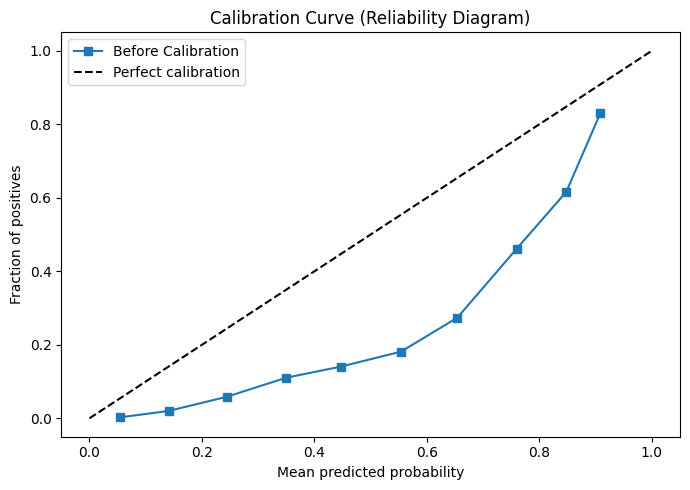

In [55]:
from sklearn.calibration import calibration_curve, CalibratedClassifierCV

# Plot calibration curve
fig, ax = plt.subplots(figsize=(7, 5))

fraction_of_positives, mean_predicted_value = calibration_curve(y_test, y_proba, n_bins=10)
ax.plot(mean_predicted_value, fraction_of_positives, "s-", label="Before Calibration")
ax.plot([0, 1], [0, 1], "k--", label="Perfect calibration")
ax.set_xlabel("Mean predicted probability")
ax.set_ylabel("Fraction of positives")
ax.set_title("Calibration Curve (Reliability Diagram)")
ax.legend()
plt.tight_layout()
plt.show()

> **Observation:** Model menunjukkan pola *underconfident* — probabilitas yang diprediksi cenderung lebih rendah dari actual positive rate, terutama di range 0.4–0.9. Namun untuk tujuan proyek ini (prioritisasi panggilan berdasarkan ranking skor), kalibrasi yang sempurna tidak diperlukan. Yang penting adalah model mampu membedakan nasabah yang berpotensi subscribe vs tidak secara relatif, bukan nilai probabilitas absolutnya.

## **6.7 Model Explanation and Interpretation**


### 6.7.1 Feature Importance


In [60]:
preprocessor_step = best_model.named_steps['preprocessor']
feature_names_all = preprocessor_step.get_feature_names_out()

print(f"Total features after preprocessing: {len(feature_names_all)}")
print(f"Features: {list(feature_names_all)}")

Total features after preprocessing: 59
Features: ['num__age', 'num__duration', 'num__campaign', 'num__pdays', 'num__previous', 'num__emp.var.rate', 'num__cons.price.idx', 'num__cons.conf.idx', 'num__euribor3m', 'num__nr.employed', 'cat__job_admin.', 'cat__job_blue-collar', 'cat__job_entrepreneur', 'cat__job_housemaid', 'cat__job_management', 'cat__job_retired', 'cat__job_self-employed', 'cat__job_services', 'cat__job_student', 'cat__job_technician', 'cat__job_unemployed', 'cat__marital_divorced', 'cat__marital_married', 'cat__marital_single', 'cat__education_basic.4y', 'cat__education_basic.6y', 'cat__education_basic.9y', 'cat__education_high.school', 'cat__education_illiterate', 'cat__education_professional.course', 'cat__education_university.degree', 'cat__default_no', 'cat__default_unknown', 'cat__default_yes', 'cat__housing_no', 'cat__housing_yes', 'cat__loan_no', 'cat__loan_yes', 'cat__contact_cellular', 'cat__contact_telephone', 'cat__month_apr', 'cat__month_aug', 'cat__month_dec

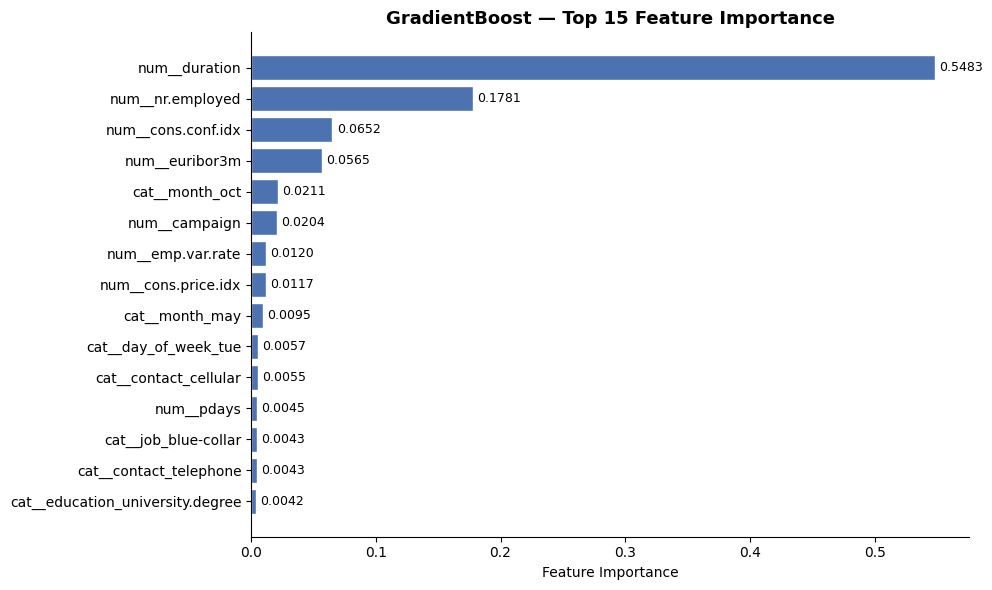

,Feature,Importance
0,num__duration,0.548320
1,num__nr.employed,0.178127
2,num__cons.conf.idx,0.065166
3,num__euribor3m,0.056462
4,cat__month_oct,0.021110
5,num__campaign,0.020444
6,num__emp.var.rate,0.011981
7,num__cons.price.idx,0.011671
8,cat__month_may,0.009520
9,cat__day_of_week_tue,0.005700


In [ ]:
gb_clf      = best_model.named_steps['model']
importances = gb_clf.feature_importances_

feature_imp_df = pd.DataFrame({
    'Feature'   : feature_names_all,
    'Importance': importances
}).sort_values('Importance', ascending=False).reset_index(drop=True)

top_n = 15
plot_df = feature_imp_df.head(top_n)

plt.figure(figsize=(10, 6))
bars = plt.barh(
    plot_df['Feature'][::-1],
    plot_df['Importance'][::-1],
    color='#4C72B0',
    edgecolor='white'
)
plt.bar_label(bars, fmt='%.4f', padding=3, fontsize=9)
plt.xlabel('Feature Importance')
plt.title('GradientBoost — Top 15 Feature Importance', fontsize=13, fontweight='bold')
plt.gca().spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

display(feature_imp_df)

In [ ]:
import shap

# Get preprocessed data
x_test_preprocessed = best_model.named_steps['preprocessor'].transform(x_test)
x_test_preprocessed_df = pd.DataFrame(x_test_preprocessed, columns=feature_names_all)

classifier = best_model.named_steps['model']

In [64]:
explainer   = shap.TreeExplainer(classifier)
shap_values = explainer.shap_values(x_test_preprocessed_df)

shap_values_subscribe = shap_values

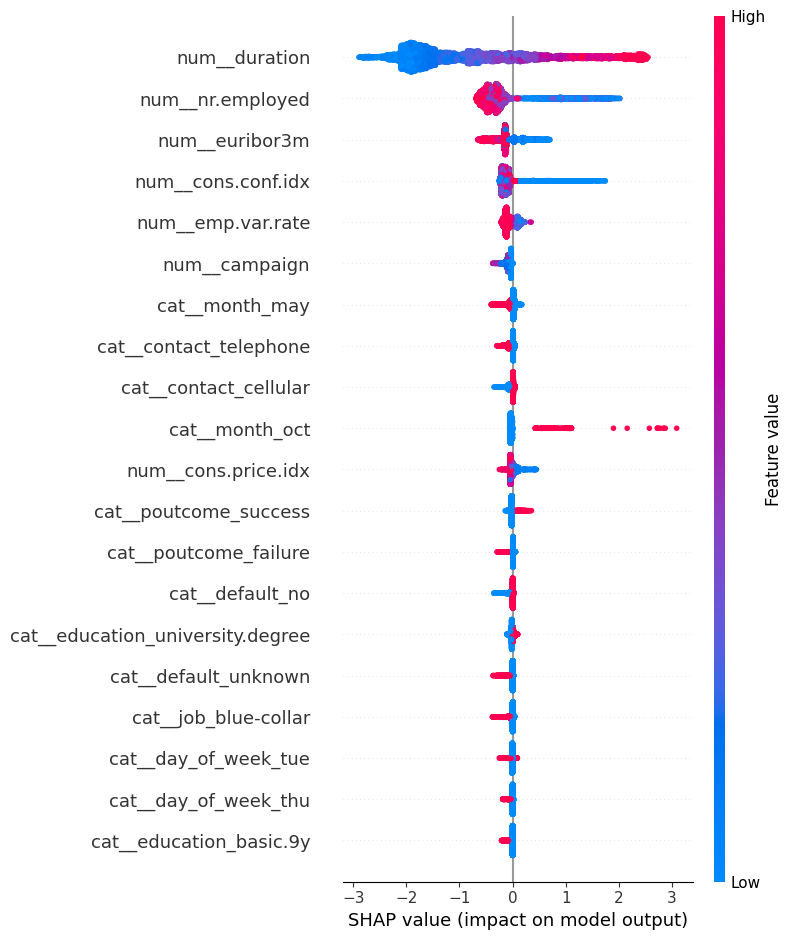

In [65]:
shap.summary_plot(shap_values_subscribe, x_test_preprocessed_df)

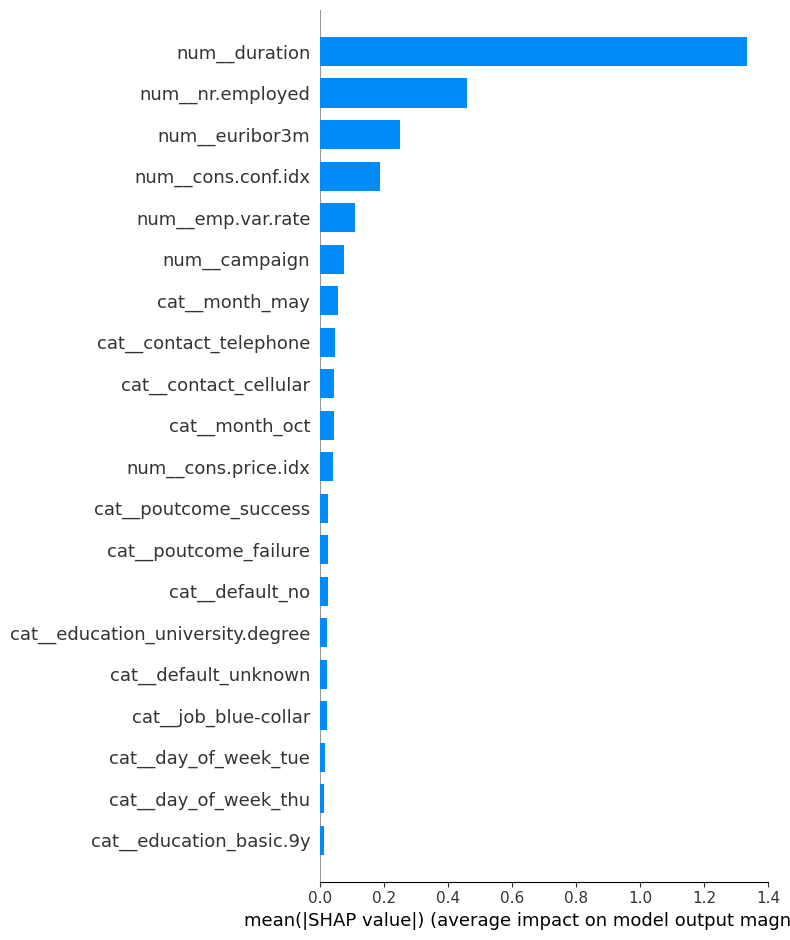

In [66]:
shap.summary_plot(shap_values_subscribe, x_test_preprocessed_df, plot_type="bar")

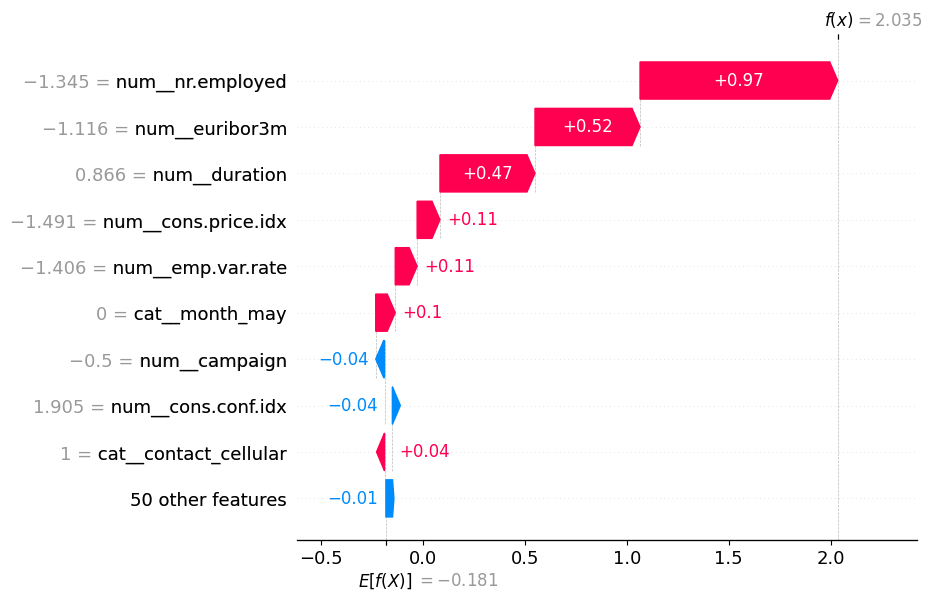

In [70]:
subscribe_indices = np.where(best_model.predict(x_test) == 1)[0]

shap_exp = shap.Explanation(
    values=shap_values_subscribe,
    base_values=explainer.expected_value[0],
    data=x_test_preprocessed_df.values,
    feature_names=feature_names_all
)

shap.plots.waterfall(shap_exp[subscribe_indices[0]])

# **Section 7. Model Deployment**


## **7.1 Export Model**


In [ ]:
import platform
import imblearn

best_model.fit(feature, target)
print(f"Refitted model to full dataset: {feature.shape}")

os.makedirs('../model', exist_ok=True)
joblib.dump({'model': best_model, 'best_score': gb_cv_score}, '../model/best_model.joblib')
print("Model saved: ../model/best_model.joblib")

loaded_model = joblib.load('../model/best_model.joblib')['model']
y_pred_loaded = loaded_model.predict(x_test)
print("\nModel loaded successfully:")
print(f"  Recall    : {recall_score(y_test, y_pred_loaded):.4f}")
print(f"  F2        : {fbeta_score(y_test, y_pred_loaded, beta=2):.4f}")
print(f"  Konsisten dengan best_model: {(y_pred_loaded == best_model.predict(x_test)).all()}")

Refitted model to full dataset: (41167, 21)
Model saved: ../model/best_model.joblib

Model loaded successfully:
  Recall    : 0.9148
  F2        : 0.7718
  Konsisten dengan best_model: True


## **7.2 Deployment Checklist**
- Versi library yang digunakan
- Format input yang diharapkan model
- Cara memuat ulang pipeline

In [73]:
print("=" * 55)
print("DEPLOYMENT CHECKLIST")
print("=" * 55)

print("\n Library Versions:")
print(f"  Python          : {platform.python_version()}")
print(f"  scikit-learn    : {sklearn.__version__}")
print(f"  imbalanced-learn: {imblearn.__version__}")
print(f"  pandas          : {pd.__version__}")
print(f"  numpy           : {np.__version__}")

print("\n Expected Input Format:")
print(f"  Tipe  : pandas DataFrame")
print(f"  Shape : (n_samples, {feature.shape[1]}) — {feature.shape[1]} kolom")
print(f"  Kolom : {list(feature.columns)}")

print("\n Pipeline Steps:")
for step_name, step_obj in best_model.steps:
    print(f"  {step_name:<25}: {step_obj.__class__.__name__}")

print("\n Best Parameters (GradientBoost):")
gb_params = best_model.named_steps['model'].get_params()
for k, v in gb_params.items():
    print(f"  {k:<30}: {v}")

print("\n Final Performance (Test Set):")
y_pred_final = best_model.predict(x_test)
print(f"  Recall    : {recall_score(y_test, y_pred_final):.4f}")
print(f"  Precision : {precision_score(y_test, y_pred_final):.4f}")
print(f"  F2        : {fbeta_score(y_test, y_pred_final, beta=2):.4f}")
print(f"  ROC-AUC   : {roc_auc_score(y_test, best_model.predict_proba(x_test)[:,1]):.4f}")

print("\n How to Load Model:")
print("  import joblib")
print("  model = joblib.load('../model/best_model.joblib')['model']")
print("  predictions = model.predict(df_input)")
print("  probabilities = model.predict_proba(df_input)[:, 1]")

print("\n Model ready for deployment.")

DEPLOYMENT CHECKLIST

 Library Versions:
  Python          : 3.14.4
  scikit-learn    : 1.8.0
  imbalanced-learn: 0.14.2
  pandas          : 3.0.3
  numpy           : 2.4.6

 Expected Input Format:
  Tipe  : pandas DataFrame
  Shape : (n_samples, 21) — 21 kolom
  Kolom : ['age', 'job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'day_of_week', 'duration', 'campaign', 'pdays', 'previous', 'poutcome', 'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed', 'was_previously_contacted']

 Pipeline Steps:
  preprocessor             : ColumnTransformer
  smote                    : SMOTE
  model                    : GradientBoostingClassifier

 Best Parameters (GradientBoost):
  ccp_alpha                     : 0.0
  criterion                     : friedman_mse
  init                          : None
  learning_rate                 : 0.012074830777139991
  loss                          : log_loss
  max_depth                     : 5
  max_featu

# **Section 8. Model Implementation**


## **8.1 How to implement the model?**


In [77]:
# Load the saved model
model = joblib.load('../model/best_model.joblib')['model']

# Predict class (0 = Not Subscribe, 1 = Subscribe)
y_pred_new   = model.predict(x_test)
y_proba_new  = model.predict_proba(x_test)[:, 1]

# Create output dataframe
output_df = x_test.copy().reset_index(drop=True)
output_df['Subscribe_Prediction'] = y_pred_new
output_df['Subscribe_Probability'] = y_proba_new.round(4)
output_df['Likelihood_Label'] = pd.cut(
    y_proba_new,
    bins=[0, 0.3, 0.6, 1.0],
    labels=['Low Likelihood', 'Medium Likelihood', 'High Likelihood']
)

print("Sample prediction output:")
display(output_df[['Subscribe_Prediction', 'Subscribe_Probability', 'Likelihood_Label']].head(10))
print(f"\nTotal nasabah diprediksi Subscribe: {y_pred_new.sum()} / {len(y_pred_new)}")
print(f"Persentase: {y_pred_new.sum() / len(y_pred_new) * 100:.2f}%")

Sample prediction output:


,Subscribe_Prediction,Subscribe_Probability,Likelihood_Label
0,0,0.0466,Low Likelihood
1,0,0.0425,Low Likelihood
2,1,0.8723,High Likelihood
3,0,0.0480,Low Likelihood
4,0,0.0801,Low Likelihood
5,0,0.0422,Low Likelihood
6,0,0.0434,Low Likelihood
7,0,0.0502,Low Likelihood
8,0,0.0563,Low Likelihood
9,0,0.0449,Low Likelihood



Total nasabah diprediksi Subscribe: 1786 / 8234
Persentase: 21.69%
